In [1]:
import os
from json.decoder import NaN

import dill
import numpy as np
import pandas as pd
# import plotly.graph_objects as go
from numpy.ma.core import clip
from sklearn.metrics import r2_score
from IPython.display import display
from sympy.physics.control.control_plots import matplotlib

from ecoli.library.schema import bulk_name_to_idx

os.chdir(os.path.expanduser('~/dev/vEcoli'))
os.makedirs('notebooks/cofactors/buffer_figures', exist_ok=True)

# ── Constants ────────────────────────────────────────────────────────────────
AVOGADRO = 6.02214076e23                                # molecules / mol
CELL_VOLUME_FL = {"Minimal": 1.44983, "Rich": 3.073264}  # femtolitres
TARGET_METALS  = ["FE", "ZN", "MN", "CU", "MO", "NI", "CO"]

# ── Plot style ────────────────────────────────────────────────────────────────
COLORS  = {"Minimal": "steelblue", "Rich": "tomato"}
SYMBOLS = {"Minimal": "circle",    "Rich": "diamond"}

In [2]:
# ── Helper functions ──────────────────────────────────────────────────────────
def atoms_to_M(atoms: float, vol_fL: float) -> float:
    """Convert atoms/cell → mol/L (plain float, no unit objects)."""
    return float(atoms) / (AVOGADRO * vol_fL * 1e-15)

def M_to_atoms(conc:float, vol_fL: float) -> float:
    """Convert concentration in M (mol/L) to atoms/cell"""
    return conc * AVOGADRO * vol_fL * 1e-15

def load_sim(folder_path: str):
    """Load simulation output; return (bulk DataFrame, metabolism step agent)."""
    output = np.load(folder_path + '0_output.npy', allow_pickle=True).item()
    output = output['agents']['0']
    bulk   = pd.DataFrame(output['bulk'])
    with open(folder_path + 'agent_steps.pkl', 'rb') as fh:
        agent = dill.load(fh)
    metabolism = agent['ecoli-metabolism-redux-classic']
    return bulk, metabolism


def get_sim_buf_concs(
    bulk, metabolism, buffers: list[str], vol_fL: float
) -> pd.Series:
    """
    Return mean steady-state concentrations (M) for *buffers* as a Series
    indexed by molecule name.
    """
    idx        = bulk_name_to_idx(buffers, metabolism.bulk_ids)
    mean_cnts  = pd.DataFrame(bulk[idx]).mean(axis=0).values
    concs_M    = mean_cnts / (AVOGADRO * vol_fL * 1e-15)
    return pd.Series(concs_M, index=buffers, name='conc_M', dtype=float)

---
## 1. Deficit DataFrames

$$\text{deficit}_\text{M} = [\text{Metal}]_{\text{ICP}} - [\text{Metal}]_{\text{sim}}$$

Uncertainty propagated in quadrature from ICP-MS and simulation standard deviations.

In [3]:
raw = pd.read_csv('notebooks/cofactors/data/metals_plot_data.csv')
raw['Element'] = raw['Element'].str.replace('"', '').str.strip()
raw['Medium']  = raw['Medium'].str.replace('"', '').str.strip()
raw = raw[raw['Element'].isin(TARGET_METALS)].copy()

# Convert atoms/cell → M for both conditions
for cond in ['Minimal', 'Rich']:
    mask = raw['Medium'] == cond
    vol  = CELL_VOLUME_FL[cond]

    raw.loc[mask, 'icp_M']   = (raw.loc[mask, 'Atoms/cell (experiment)']
                                .apply(lambda x: atoms_to_M(x, vol)))
    raw.loc[mask, 'sim_M']   = (raw.loc[mask, 'Atoms/cell (simulation)']
                                .apply(lambda x: atoms_to_M(x, vol)))

    deficit_atoms = (
        raw.loc[mask, 'Atoms/cell (experiment)']
        - raw.loc[mask, 'Atoms/cell (simulation)']
    )
    deficit_err_atoms = np.sqrt(
        raw.loc[mask, 'Atoms/cell (experiment), stddev'] ** 2
        + raw.loc[mask, 'Atoms/cell (simulation), stddev'] ** 2
    )
    raw.loc[mask, 'deficit_M']     = deficit_atoms.apply(lambda x: atoms_to_M(x, vol))
    raw.loc[mask, 'deficit_M_err'] = deficit_err_atoms.apply(lambda x: atoms_to_M(x, vol))

DEFICIT_COLS = ['icp_M', 'sim_M', 'deficit_M', 'deficit_M_err']

# ── Split by medium, Element as index ────────────────────────────────────────
deficit_minimal = (
    raw[raw['Medium'] == 'Minimal']
    .set_index('Element')[DEFICIT_COLS]
    .astype(float)
)
deficit_rich = (
    raw[raw['Medium'] == 'Rich']
    .set_index('Element')[DEFICIT_COLS]
    .astype(float)
)

In [4]:
print('=== deficit_minimal (Element × 4) ===')
display(deficit_minimal.style.format('{:.3e}'))

print('\n=== deficit_rich (Element × 4) ===')
display(deficit_rich.style.format('{:.3e}'))

=== deficit_minimal (Element × 4) ===


,icp_M,sim_M,deficit_M,deficit_M_err
Element,,,,
FE,2.061e-04,3.065e-04,-1.004e-04,3.430e-05
CU,8.992e-06,9.729e-06,-7.371e-07,1.512e-06
CO,5.957e-07,0.000e+00,5.957e-07,1.145e-06
NI,4.329e-06,7.835e-07,3.546e-06,1.154e-06
ZN,2.288e-04,2.463e-04,-1.742e-05,6.533e-05
MO,4.562e-06,2.508e-06,2.054e-06,1.188e-06



=== deficit_rich (Element × 4) ===


,icp_M,sim_M,deficit_M,deficit_M_err
Element,,,,
CU,4.732e-05,8.219e-06,3.910e-05,1.588e-05
MO,5.834e-06,1.861e-06,3.972e-06,5.808e-07
NI,1.751e-06,6.942e-07,1.057e-06,5.487e-07
ZN,2.159e-04,1.930e-04,2.290e-05,4.917e-05
CO,2.397e-07,0.000e+00,2.397e-07,5.403e-08
MN,2.526e-05,3.750e-05,-1.224e-05,7.271e-06
FE,3.281e-04,2.673e-04,6.076e-05,7.159e-05


---
## 2. Load Simulation

In [5]:
bulk_basal, metabolism = load_sim(
    'out_cyrus/basal/metabolism_classic_1500_2026-03-24/'
)
bulk_rich, _ = load_sim(
    'out_cyrus/with_aa/metabolism_classic_1500_2026-03-24/'
)
print('Simulation loaded.  bulk_basal shape:', bulk_basal.shape,
      ' | bulk_rich shape:', bulk_rich.shape)

Simulation loaded.  bulk_basal shape: (1501, 16324)  | bulk_rich shape: (1501, 16324)


---
## 3. Buffer Constants

Columns 0–1: literature free-metal concentrations (M)
Columns 2–3: experimentally measured *total* buffered metal concentrations ± std (M9/Minimal media)
Columns 4+: stability constants log(β) for each ligand

In [6]:
buf_raw = pd.read_csv('notebooks/cofactors/data/buffer_constants.csv', index_col=0)
buf_raw.index.name = 'Element'

# ── Free metal concentrations (literature, M) ─────────────────────────────
free_metal_minimal = buf_raw.iloc[:, 0].astype(float).rename('free_M')  # M9 / Minimal
free_metal_rich    = buf_raw.iloc[:, 1].astype(float).rename('free_M')  # LB / Rich

# ── Measured total buffered concentrations (M9 only) ──────────────────────
# divide by 2 to account for 50% cytosol volume of the measurements
meas_buf_minimal = buf_raw.iloc[:, 2:4].astype(float).copy() / 2
meas_buf_minimal.columns = ['measured_M', 'measured_std_M']

# ── Stability constants log(β): Element × buffer ──────────────────────────
stability = buf_raw.iloc[:, 4:].astype(float).copy()
stability_ub = stability + 1
stability_lb = stability - 1


# ── Look-up dicts (same structure as original) ────────────────────────────
buffer_to_metal_ub: dict[str, dict[str, float]] = {}   # buf  → {metal: logβ}
metal_to_buffer_ub: dict[str, dict[str, float]] = {}   # metal → {buf: logβ}
buffer_to_metal_lb: dict[str, dict[str, float]] = {}   # buf  → {metal: logβ}
metal_to_buffer_lb: dict[str, dict[str, float]] = {}   # metal → {buf: logβ}

for buf in stability.columns:
    row_ub = stability_ub[buf].dropna()
    row_lb = stability_lb[buf].dropna()
    if not row_ub.empty:
        buffer_to_metal_ub[buf] = row_ub.to_dict()
        buffer_to_metal_lb[buf] = row_lb.to_dict()

for buf, metals_dict in buffer_to_metal_ub.items():
    for metal, logbeta in metals_dict.items():
        metal_to_buffer_ub.setdefault(metal, {})[buf] = logbeta

for buf, metals_dict in buffer_to_metal_lb.items():
    for metal, logbeta in metals_dict.items():
        metal_to_buffer_lb.setdefault(metal, {})[buf] = logbeta

ALL_BUFFERS = list(buffer_to_metal_ub.keys())
ALL_METALS  = list(free_metal_minimal.index)

In [7]:
print('=== free_metal_minimal (Element Series, M) ===')
display(free_metal_minimal.to_frame().style.format('{:.3e}'))

print('\n=== meas_buf_minimal (Element × 2, M) ===')
display(meas_buf_minimal.style.format('{:.3e}'))

print('\n=== stability (Element × buffer, log β) ===')
display(stability)

print('\nBuffers with stability data:', ALL_BUFFERS)

=== free_metal_minimal (Element Series, M) ===


,free_M
Element,
MG,2.700e-03
MN,2.080e-06
FE,6.180e-08
CO,2.420e-10
NI,2.560e-12
CU,1.460e-20
ZN,1.040e-11



=== meas_buf_minimal (Element × 2, M) ===


,measured_M,measured_std_M
Element,,
MG,1.490e-02,1.145e-03
MN,7.000e-07,3.500e-07
FE,4.000e-05,1.000e-05
CO,nan,nan
NI,7.500e-06,1.000e-06
CU,5.000e-06,1.000e-06
ZN,6.500e-06,1.500e-06



=== stability (Element × buffer, log β) ===


,GLUTATHIONE[c],CYS[c],HIS[c],OXIDIZED-GLUTATHIONE[c],L-ASPARTATE[c],MET[c],L-ALPHA-ALANINE[c],LEU[c],VAL[c],GLY[c],TRP[c],ATP[c],CIT[c]
Element,,,,,,,,,,,,,
MG,NaN,2.75,NaN,NaN,2.40,NaN,1.96,NaN,NaN,1.66,NaN,4.03,3.44
MN,2.70,4.75,3.240000,NaN,3.91,2.77,2.43,2.30,2.32,2.27,2.54,4.76,3.79
FE,5.10,6.20,5.883093,NaN,4.34,3.24,3.54,3.42,3.39,NaN,NaN,5.18,4.56
CO,NaN,8.14,6.700000,NaN,5.90,4.17,4.32,4.49,4.24,4.64,4.47,4.60,4.90
NI,7.37,9.60,8.430000,9.08,7.16,5.27,5.26,5.33,5.09,5.59,5.35,4.86,5.30
CU,11.60,11.10,9.820000,13.37,8.75,7.68,7.94,7.97,7.96,7.99,8.01,6.34,8.22
ZN,7.98,9.11,6.350000,7.60,5.82,4.30,4.54,4.51,4.47,4.87,4.54,5.16,4.64



Buffers with stability data: ['GLUTATHIONE[c]', 'CYS[c]', 'HIS[c]', 'OXIDIZED-GLUTATHIONE[c]', 'L-ASPARTATE[c]', 'MET[c]', 'L-ALPHA-ALANINE[c]', 'LEU[c]', 'VAL[c]', 'GLY[c]', 'TRP[c]', 'ATP[c]', 'CIT[c]']


---
## 4. Simulation Buffer Concentrations

Mean steady-state concentrations across all simulation time-steps, converted to mol/L.

In [8]:
sim_buf_minimal = get_sim_buf_concs(
    bulk_basal, metabolism, ALL_BUFFERS, CELL_VOLUME_FL['Minimal']
)
sim_buf_rich = get_sim_buf_concs(
    bulk_rich, metabolism, ALL_BUFFERS, CELL_VOLUME_FL['Rich']
)

# sim_buf_minimal = pd.read_csv("notebooks/cofactors/data/sim_buf_minimal.csv", index_col=0)
# sim_buf_rich = pd.read_csv("notebooks/cofactors/data/sim_buf_rich.csv", index_col=0)
# ── Display side by side ───────────────────────────────────────────────────
sim_buf_display = pd.concat(
    [sim_buf_minimal.rename('Minimal'), sim_buf_rich.rename('Rich')], axis=1
)
print('=== sim_buf_minimal / sim_buf_rich (buffer Series, M) ===')
display(sim_buf_display.style.format('{:.3e}'))

=== sim_buf_minimal / sim_buf_rich (buffer Series, M) ===


,Minimal,Rich
GLUTATHIONE[c],9.790e-03,1.199e-02
CYS[c],1.807e-05,4.426e-05
HIS[c],6.100e-05,1.494e-04
OXIDIZED-GLUTATHIONE[c],1.122e-03,1.374e-03
L-ASPARTATE[c],2.109e-03,5.166e-03
MET[c],6.757e-05,1.655e-04
L-ALPHA-ALANINE[c],9.288e-04,2.275e-03
LEU[c],1.265e-04,1.677e-03
VAL[c],2.539e-04,6.220e-04
GLY[c],5.191e-04,1.272e-03


---
## 5. Approach 1 – Competition Model

**Step 1** – free buffer concentration (accounting for metal competition)

$$[L_\text{free}] = \frac{[L_\text{total}]}{1 + \sum_M K_{A,M} \cdot [M_\text{free}]}$$

**Step 2** – total buffered metal concentration

$$[M_\text{buffered}] = [M_\text{free}] \cdot \left(1 + \sum_L K_{A,L} \cdot [L_\text{free}]\right)$$

> **Note:** Following the original analysis, `free_metal_minimal` is used for the competition factor in *both* conditions.  Only the simulation-derived buffer concentrations (`sim_buf_minimal` vs `sim_buf_rich`) differ.

In [9]:
def estimate_buffered_competition(
    metals: list[str],
    free_metal: pd.Series,
    sim_buf: pd.Series,
    metal_to_buffer: dict,
    buffer_to_metal: dict,
) -> pd.Series:
    free_metal_d = free_metal.to_dict()
    sim_buf_d    = sim_buf.to_dict()

    # ── Step 1: free buffer concentrations ───────────────────────────────────
    #
    # Ligand mass balance (1:1 stoichiometry only):
    #   [L]_total = [L]_free + Σ_M β_ML * [M]_free * [L]_free
    #             = [L]_free * (1 + Σ_M β_ML * [M]_free)
    #
    #   → [L]_free = [L]_total / (1 + Σ_M β_ML * [M]_free)

    free_buf: dict[str, float] = {}
    for buf in set(buffer_to_metal):
        total = sim_buf_d.get(buf, 0.0)
        B = 1.0
        for m, lb in buffer_to_metal.get(buf, {}).items():
            B += 10 ** lb * free_metal_d.get(m, 0.0)
        free_buf[buf] = total / B

    # ── Step 2: total (free + small-molecule-chelated) metal ─────────────────
    #
    # Metal mass balance (1:1 stoichiometry only):
    #   [M]_total = [M]_free * (1 + Σ_L β_ML * [L]_free)

    result: dict[str, float] = {}
    for metal in metals:
        free_m = free_metal_d.get(metal, 0.0)
        comp   = sum(
            10 ** lb * free_buf.get(buf, 0.0)
            for buf, lb in metal_to_buffer.get(metal, {}).items()
        )
        result[metal] = free_m * (1 + comp)

    return pd.Series(result, name='est_competition_M', dtype=float)

In [10]:
est_competition_minimal_lb = estimate_buffered_competition(
    ALL_METALS, free_metal_minimal, sim_buf_minimal,
    metal_to_buffer_lb, buffer_to_metal_lb,
)
est_competition_minimal_ub = estimate_buffered_competition(
    ALL_METALS, free_metal_minimal, sim_buf_minimal,
    metal_to_buffer_ub, buffer_to_metal_ub,
)
est_competition_rich_lb = estimate_buffered_competition(
    ALL_METALS, free_metal_rich, sim_buf_rich,
    metal_to_buffer_lb, buffer_to_metal_lb,
)
est_competition_rich_ub = estimate_buffered_competition(
    ALL_METALS, free_metal_rich, sim_buf_rich,
    metal_to_buffer_ub, buffer_to_metal_ub,
)

print('=== est_competition_minimal / est_competition_rich (Element Series, M) ===')
display(
    pd.concat([
        est_competition_minimal_lb.rename('Minimal Lower Bound'),
        est_competition_minimal_ub.rename('Minimal Upper Bound'),
        est_competition_rich_lb.rename('Rich Lower Bound'),
        est_competition_rich_ub.rename('Rich Upper Bound'),
    ], axis=1).style.format('{:.3e}')
)

=== est_competition_minimal / est_competition_rich (Element Series, M) ===


,Minimal Lower Bound,Minimal Upper Bound,Rich Lower Bound,Rich Upper Bound
MG,9.454e-03,1.491e-02,6.470e-03,1.621e-02
MN,3.242e-05,1.827e-04,2.331e-04,1.238e-03
FE,1.052e-05,7.209e-04,4.757e-04,9.474e-03
CO,1.016e-07,1.381e-06,6.630e-08,8.762e-07
NI,4.311e-07,3.919e-05,2.810e-08,2.275e-06
CU,4.407e-11,4.228e-09,1.660e-10,1.504e-08
ZN,1.040e-06,9.315e-05,1.145e-06,3.667e-05


---
## 6. Approach 2 – Simplified Model

Same as Approach 1 but the free buffer concentration equals the total simulation concentration (no cross-metal competition correction for ligand occupancy):

$$[M_\text{buffered}] = [M_\text{free}] \cdot \left(1 + \sum_L K_{A,L} \cdot [L_\text{total}]\right)$$

In [11]:
def estimate_buffered_simplified(
    metals: list[str],
    free_metal: pd.Series,
    sim_buf: pd.Series,
    metal_to_buffer: dict,
) -> pd.Series:
    """
    Simplified model: uses total (not free) buffer concentrations.
    1:1 stoichiometry only.
    """
    free_metal_d = free_metal.to_dict()
    sim_buf_d    = sim_buf.to_dict()

    result: dict[str, float] = {}
    for metal in metals:
        free_m = free_metal_d.get(metal, 0.0)
        comp   = sum(
            10 ** lb * sim_buf_d.get(buf, 0.0)
            for buf, lb in metal_to_buffer.get(metal, {}).items()
        )
        result[metal] = free_m * (1 + comp)

    return pd.Series(result, name='est_simplified_M', dtype=float)

In [12]:
est_simplified_minimal_lb = estimate_buffered_simplified(
    ALL_METALS, free_metal_minimal, sim_buf_minimal, metal_to_buffer_lb
)
est_simplified_minimal_ub = estimate_buffered_simplified(
    ALL_METALS, free_metal_minimal, sim_buf_minimal, metal_to_buffer_ub
)
est_simplified_rich_lb = estimate_buffered_simplified(
    ALL_METALS, free_metal_rich, sim_buf_rich, metal_to_buffer_lb
)
est_simplified_rich_ub = estimate_buffered_simplified(
    ALL_METALS, free_metal_rich, sim_buf_rich, metal_to_buffer_ub
)

print('=== est_simplified_minimal / est_simplified_rich (Element Series, M) ===')
display(
    pd.concat([
        est_simplified_minimal_lb.rename('Minimal Lower Bound'),
        est_simplified_minimal_ub.rename('Minimal Upper Bound'),
        est_simplified_rich_lb.rename('Rich Lower Bound'),
        est_simplified_rich_ub.rename('Rich Upper Bound'),
    ], axis=1).style.format('{:.3e}')
)

=== est_simplified_minimal / est_simplified_rich (Element Series, M) ===


,Minimal Lower Bound,Minimal Upper Bound,Rich Lower Bound,Rich Upper Bound
MG,2.721e-02,2.453e+00,1.220e-02,1.121e+00
MN,1.049e-04,1.029e-02,4.472e-04,4.403e-02
FE,1.630e-05,1.624e-03,6.432e-04,6.414e-02
CO,1.204e-07,1.202e-05,8.183e-08,8.176e-06
NI,4.348e-07,4.348e-05,2.895e-08,2.895e-06
CU,4.409e-11,4.409e-09,1.665e-10,1.665e-08
ZN,1.046e-06,1.046e-04,1.187e-06,1.187e-04


---
## 7. Combined Results Tables

Because every DataFrame is Element-indexed, assembling the full results is a single `pd.concat` — no merge, no groupby.

In [13]:
results_minimal = pd.concat(
    [
        deficit_minimal,
        meas_buf_minimal,
        est_competition_minimal_lb,
        est_competition_minimal_ub,
        est_simplified_minimal_lb,
        est_simplified_minimal_ub,
        free_metal_minimal,
    ],
    axis=1,
)

results_rich = pd.concat(
    [
        deficit_rich,
        est_competition_rich_lb,
        est_competition_rich_ub,
        est_simplified_rich_lb,
        est_simplified_rich_ub,
        free_metal_rich.rename('free_M_lit'),  # Minimal free-metal used for both
    ],
    axis=1,
)

print('=== results_minimal ===')
display(results_minimal.style.format('{:.3e}'))

print('\n=== results_rich ===')
display(results_rich.style.format('{:.3e}'))

=== results_minimal ===


,icp_M,sim_M,deficit_M,deficit_M_err,measured_M,measured_std_M,est_competition_M,est_competition_M,est_simplified_M,est_simplified_M,free_M
FE,2.061e-04,3.065e-04,-1.004e-04,3.430e-05,4.000e-05,1.000e-05,1.052e-05,7.209e-04,1.630e-05,1.624e-03,6.180e-08
CU,8.992e-06,9.729e-06,-7.371e-07,1.512e-06,5.000e-06,1.000e-06,4.407e-11,4.228e-09,4.409e-11,4.409e-09,1.460e-20
CO,5.957e-07,0.000e+00,5.957e-07,1.145e-06,nan,nan,1.016e-07,1.381e-06,1.204e-07,1.202e-05,2.420e-10
NI,4.329e-06,7.835e-07,3.546e-06,1.154e-06,7.500e-06,1.000e-06,4.311e-07,3.919e-05,4.348e-07,4.348e-05,2.560e-12
ZN,2.288e-04,2.463e-04,-1.742e-05,6.533e-05,6.500e-06,1.500e-06,1.040e-06,9.315e-05,1.046e-06,1.046e-04,1.040e-11
MO,4.562e-06,2.508e-06,2.054e-06,1.188e-06,nan,nan,nan,nan,nan,nan,nan
MG,nan,nan,nan,nan,1.490e-02,1.145e-03,9.454e-03,1.491e-02,2.721e-02,2.453e+00,2.700e-03
MN,nan,nan,nan,nan,7.000e-07,3.500e-07,3.242e-05,1.827e-04,1.049e-04,1.029e-02,2.080e-06



=== results_rich ===


,icp_M,sim_M,deficit_M,deficit_M_err,est_competition_M,est_competition_M,est_simplified_M,est_simplified_M,free_M_lit
CU,4.732e-05,8.219e-06,3.910e-05,1.588e-05,1.660e-10,1.504e-08,1.665e-10,1.665e-08,4.500e-20
MO,5.834e-06,1.861e-06,3.972e-06,5.808e-07,nan,nan,nan,nan,nan
NI,1.751e-06,6.942e-07,1.057e-06,5.487e-07,2.810e-08,2.275e-06,2.895e-08,2.895e-06,1.300e-13
ZN,2.159e-04,1.930e-04,2.290e-05,4.917e-05,1.145e-06,3.667e-05,1.187e-06,1.187e-04,9.400e-12
CO,2.397e-07,0.000e+00,2.397e-07,5.403e-08,6.630e-08,8.762e-07,8.183e-08,8.176e-06,7.000e-11
MN,2.526e-05,3.750e-05,-1.224e-05,7.271e-06,2.331e-04,1.238e-03,4.472e-04,4.403e-02,7.000e-06
FE,3.281e-04,2.673e-04,6.076e-05,7.159e-05,4.757e-04,9.474e-03,6.432e-04,6.414e-02,1.900e-06
MG,nan,nan,nan,nan,6.470e-03,1.621e-02,1.220e-02,1.121e+00,1.000e-03


---
## 8. Plots

### Helper: build long-form DataFrame for plotting (positive deficits only)

In [14]:
def build_plot_df(
    est_minimal_lb: pd.Series,
    est_minimal_ub: pd.Series,
    est_rich_lb: pd.Series,
    est_rich_ub: pd.Series,
    deficit_minimal: pd.DataFrame,
    deficit_rich: pd.DataFrame,
    positive_only: bool = True,
) -> pd.DataFrame:
    """
    Merge lb/ub buffered estimates with deficits into a long-form DataFrame.

    Columns: Medium, Element, est_buf_lb_M, est_buf_ub_M,
             est_buf_center_M, deficit_M, deficit_M_err
    """
    rows = []
    for cond, est_lb, est_ub, deficit_df in [
        ('Minimal', est_minimal_lb, est_minimal_ub, deficit_minimal),
        ('Rich',    est_rich_lb,    est_rich_ub,    deficit_rich),
    ]:
        for element in est_lb.index:
            if element not in deficit_df.index:
                continue
            deficit_val = deficit_df.loc[element, 'deficit_M']
            deficit_err = deficit_df.loc[element, 'deficit_M_err']
            if positive_only and deficit_val <= 0:
                continue
            lb = float(est_lb[element])
            ub = float(est_ub[element])
            rows.append({
                'Medium':            cond,
                'Element':           element,
                'est_buf_lb_M':      lb,
                'est_buf_ub_M':      ub,
                'est_buf_center_M':  (lb + ub) / 2,
                'deficit_M':         float(deficit_val),
                'deficit_M_err':     float(deficit_err),
            })
    return pd.DataFrame(rows)

### Plot 1 – Competition model: estimated buffered [Metal] vs. Estimated deficit

In [15]:
import polars as pl
import altair as alt

plot_df_comp = build_plot_df(
    est_competition_minimal_lb, est_competition_minimal_ub,
    est_competition_rich_lb,    est_competition_rich_ub,
    deficit_minimal, deficit_rich,
)

df = pl.from_pandas(plot_df_comp).with_columns([
    (pl.col("est_buf_center_M") * 1e6).alias("x_uM"),
    (pl.col("est_buf_lb_M")     * 1e6).alias("x_lb_uM"),
    (pl.col("est_buf_ub_M")     * 1e6).alias("x_ub_uM"),
    (pl.col("deficit_M")        * 1e6).alias("y_uM"),
    (pl.col("deficit_M_err")    * 1e6).alias("y_err_uM"),
])

DOMAIN_MIN = 1e-7   # just below your domain floor of 1e-6

# ── Log-axis label expression (10^n with Unicode superscripts) ────────────────
_log_label_unicode = (
    "datum.value > 0 ? '10' + "
    "replace(replace(replace(replace(replace(replace("
    "replace(replace(replace(replace(replace('' + "
    "round(log(datum.value)/LN10), '-','⁻'),'0','⁰'),'1','¹'),'2','²')"
    ",'3','³'),'4','⁴'),'5','⁵'),'6','⁶'),'7','⁷'),'8','⁸'),'9','⁹') : '0'"
)

df = df.with_columns([
    pl.max_horizontal(
        pl.col("y_uM") - pl.col("y_err_uM"),
        pl.lit(DOMAIN_MIN)
    ).alias("y_lo_uM"),
    (pl.col("y_uM") + pl.col("y_err_uM")).alias("y_hi_uM"),
])

base = alt.Chart(df).encode(
)
x_scale = alt.Scale(type="log", domain=[1e-6, 1e6])
y_scale = alt.Scale(type="log", domain=[1e-6, 1e6])

_ax_x = alt.Axis(labelExpr=_log_label_unicode, title="Modeled Buffered [Metal] [µmol/L]")
_ax_y = alt.Axis(labelExpr=_log_label_unicode, title="Estimated Deficit [µmol/L]")

ref_df = pl.DataFrame({"v": [1e-6, 1e6]})  # for reference line y=x

ref_line = alt.Chart(ref_df).mark_line(strokeDash=[4,4], color="gray").encode(
    x=alt.X("v:Q", scale=x_scale, axis=_ax_x),
    y=alt.Y("v:Q", scale=y_scale, axis=_ax_y),
)
x_bars = base.mark_errorbar(ticks=True).encode(
    x=alt.X("x_lb_uM:Q", scale=x_scale, title=""),
    x2="x_ub_uM:Q",
    y=alt.Y("y_uM:Q", scale=y_scale),
    color="Medium:N",
)
y_bars = base.mark_errorbar(ticks=True, clip=True).encode(
    x=alt.X("x_uM:Q"),
    y=alt.Y("y_lo_uM:Q",  scale=y_scale, title=""),   # explicit log scale + clamped lower
    y2=alt.Y2("y_hi_uM:Q"),
    color="Medium:N",
)
points = base.mark_point(filled=True, size=150, stroke='black', strokeWidth=1).encode(
    x=alt.X("x_uM:Q", scale=x_scale, axis=_ax_x),
    y=alt.Y("y_uM:Q", scale=y_scale, axis=_ax_y),
    color=alt.Color("Medium:N",
        scale=alt.Scale(domain=["Minimal","Rich"], range=["steelblue","tomato"])),
    shape=alt.Shape("Medium:N",
        scale=alt.Scale(domain=["Minimal","Rich"], range=["circle","diamond"])),
)
# 5. Text labels
labels = base.mark_text(dx=15, dy=-15, fontSize=12).encode(
    x=alt.X("x_uM:Q", scale=alt.Scale(type="log")),
    y=alt.Y("y_uM:Q", scale=alt.Scale(type="log")),
    text="Element:N",
)
chart = (ref_line + x_bars + y_bars + points + labels).properties(
    width=600, height=480,
    title="Buffered Metal Concentration vs. Deficit Fig1C – Competition Model"
).configure_axis(gridColor='#f3f6fa')
# chart.save('notebooks/cofactors/buffer_figures/buffered_metal_vs_deficit_competition.svg')
# chart

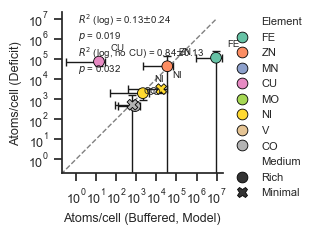

In [16]:
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np
import polars as pl

plot_df_comp = build_plot_df(
    M_to_atoms(est_competition_minimal_lb, CELL_VOLUME_FL['Minimal']),
    M_to_atoms(est_competition_minimal_ub, CELL_VOLUME_FL['Minimal']),
    M_to_atoms(est_competition_rich_lb, CELL_VOLUME_FL['Rich']),
    M_to_atoms(est_competition_rich_ub, CELL_VOLUME_FL['Rich']),
    M_to_atoms(deficit_minimal, CELL_VOLUME_FL['Minimal']),
    M_to_atoms(deficit_rich, CELL_VOLUME_FL['Rich'])
).sort_values("Medium", ascending=False)

# df = pl.from_pandas(plot_df_comp).with_columns([
#     (pl.col("est_buf_center_M") * 1e6).alias("x_uM"),
#     (pl.col("est_buf_lb_M")     * 1e6).alias("x_lb_uM"),
#     (pl.col("est_buf_ub_M")     * 1e6).alias("x_ub_uM"),
#     (pl.col("deficit_M")        * 1e6).alias("y_uM"),
#     (pl.col("deficit_M_err")    * 1e6).alias("y_err_uM"),
# ])

df = pl.from_pandas(plot_df_comp).with_columns([
    (pl.col("est_buf_center_M") ).alias("x_count"),
    (pl.col("est_buf_lb_M")).alias("x_lb_count"),
    (pl.col("est_buf_ub_M")).alias("x_ub_count"),
    (pl.col("deficit_M")).alias("y_count"),
    (pl.col("deficit_M_err")).alias("y_err_count"),
])


sns.set_theme(style="ticks")

plot_df = df.to_pandas()

# Build a consistent color map keyed by Element
elements = sorted(plot_df["Element"].unique())
elements = ['FE', 'ZN', 'MN', 'CU', 'MO', 'NI', 'V', 'CO',]
palette   = sns.color_palette("Set2", n_colors=len(elements))
color_map = dict(zip(elements, palette))

fig, ax = plt.subplots(figsize=(4, 2.5))

# ── Reference line y = x ──────────────────────────────────────────────────────
ref = np.logspace(-1, 7, 300)
ax.plot(ref, ref, ls="--", color="gray", lw=1, zorder=0)


# ── Scatter ───────────────────────────────────────────────────────────────────
sns.scatterplot(
    data=plot_df,
    x="x_count",
    y="y_count",
    hue="Element",
    style="Medium",
    palette="Set2",
    hue_order=elements,
    markers={"Minimal": "X", "Rich": "o"},
    s=60,
    edgecolor="black",
    linewidth=0.6,
    ax=ax,
    zorder=2,
)

# ── Error bars  ─────────────────────
for _, row in plot_df.iterrows():
    c = color_map[row["Element"]]
    ax.errorbar(
        row["x_count"], row["y_count"],
        xerr=[[row["x_count"]  - row["x_lb_count"]],
              [row["x_ub_count"] - row["x_count"]]],
        yerr=row["y_err_count"],
        fmt="none",
        color='k',
        capsize=3,
        lw=0.8,
        zorder=-1,
        elinewidth = 1,
    )

# ── Element text labels ───────────────────────────────────────────────────────
for _, row in plot_df.iterrows():
    ax.annotate(
        row["Element"],
        xy=(row["x_count"], row["y_count"]),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=7,
    )

# ── Stats on log10 scale (matches the visual axes) ───────────────────────────
log_x = np.log10(plot_df["x_count"])
log_y = np.log10(plot_df["y_count"])
slope, intercept, r_value, p_value_fit, std_err = stats.linregress(log_x, log_y)
r_squared = r_value ** 2
# Two-sided t-test: H0 slope == 1
t_stat   = (slope - 1) / std_err
p_slope1 = 2 * stats.t.sf(np.abs(t_stat), df=len(log_x) - 2)
def _fmt_p(p):
    if p < 0.001:
        return "$p$ < 0.001"
    return f"$p$ = {p:.3f}"

# ── Stats on log10 scale without CU ──────────────────
_temp_df = plot_df[plot_df['Element'] != "CU"]
# _temp_df = plot_df[(plot_df['Element'] != "CU") & (plot_df['Element'] != "FE")]
log_x = np.log10(_temp_df["x_count"])
log_y = np.log10(_temp_df["y_count"])

slope_2, intercept, r_value_2, p_value_fit, std_err_2 = stats.linregress(log_x, log_y)
r_squared_2 = r_value_2 ** 2
# Two-sided t-test: H0 slope == 1
t_stat_2   = (slope_2 - 1) / std_err_2
p_slope1_2 = 2 * stats.t.sf(np.abs(t_stat_2), df=len(log_x) - 2)

# ── Annotation: top-right corner ─────────────────────────────────────────────
stats_text = (
    f"$R^2$ (log) = {r_squared:.2f}" +  r'$\pm$' f'{std_err:.2f} \n'
    f"{_fmt_p(p_slope1)}\n"
    f"$R^2$ (log, no CU) = {r_squared_2:.2f}" +  r'$\pm$' f'{std_err_2:.2f} \n'
    f"{_fmt_p(p_slope1_2)}"
)
ax.text(
    0.1, 1,
    stats_text,
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=7,
    # bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="0.8", alpha=0.85),
)

# ── Log scales & limits ───────────────────────────────────────────────────────
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(2e-1, 2e7)
ax.set_ylim(2e-1, 2e7)

def _log_fmt(x, _):
    exp = int(np.round(np.log10(x)))
    return f"$10^{{{exp}}}$"

# ax.xaxis.set_major_formatter(ticker.FuncFormatter(_log_fmt), )
# ax.yaxis.set_major_formatter(ticker.FuncFormatter(_log_fmt))
ax.xaxis.set_major_locator(ticker.LogLocator(base=10, numticks=8))
ax.yaxis.set_major_locator(ticker.LogLocator(base=10, numticks=8))
ax.tick_params(axis='both', labelsize=9, labelfontfamily="sans-serif")
ax.set_xlabel("Atoms/cell (Buffered, Model)", fontsize=9)
ax.set_ylabel("Atoms/cell (Deficit)", fontsize=9)
# ax.set_title("Buffered Metal Concentration vs. Deficit – Competition Model", fontsize=10)

# ── Legend outside ────────────────────────────────────────────────────────────
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0, frameon=False, fontsize=8)

sns.despine()
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
%matplotlib inline

plt.savefig('notebooks/cofactors/buffer_figures/buffered_metal_vs_deficit_competition_matplotlib.svg')
plt.show()


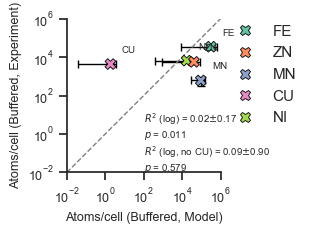

In [17]:
# ── Buffer model (competition, Minimal) vs. measured buffered metal ───────────
# x: model estimate (atoms/cell), y: measured buffered metal (atoms/cell)

_model_lb = M_to_atoms(est_competition_minimal_lb, CELL_VOLUME_FL['Minimal'])
_model_ub = M_to_atoms(est_competition_minimal_ub, CELL_VOLUME_FL['Minimal'])
_meas_cnts = meas_buf_minimal['measured_M'].apply(
    lambda v: M_to_atoms(v, CELL_VOLUME_FL['Minimal'])
)
_meas_err_cnts = meas_buf_minimal['measured_std_M'].apply(
    lambda v: M_to_atoms(v, CELL_VOLUME_FL['Minimal'])
)

_common = sorted(
    set(_model_lb.index) & set(_meas_cnts.dropna().index) & set(TARGET_METALS)
)

_rows = []
for el in _common:
    lb = float(_model_lb[el])
    ub = float(_model_ub[el])
    meas = float(_meas_cnts[el])
    meas_err = float(_meas_err_cnts[el])
    if meas <= 0 or np.isnan(meas):
        continue
    _rows.append({
        'Element': el,
        'x_count': (lb + ub) / 2,
        'x_lb_count': lb,
        'x_ub_count': ub,
        'y_count': meas,
        'y_err_count': meas_err,
    })

_plot_df_buf = pd.DataFrame(_rows)

sns.set_theme(style="ticks")

_elements_buf = [
    e for e in ['FE', 'ZN', 'MN', 'CU', 'MO', 'NI', 'V', 'CO']
    if e in _plot_df_buf['Element'].values
]
_palette_buf = sns.color_palette("Set2", n_colors=len(_elements_buf))
_color_map_buf = dict(zip(_elements_buf, _palette_buf))

fig2, ax2 = plt.subplots(figsize=(4, 2.5))

_ref = np.logspace(-2, 7, 300)
ax2.plot(_ref, _ref, ls="--", color="gray", lw=1, zorder=0)

sns.scatterplot(
    data=_plot_df_buf,
    x="x_count",
    y="y_count",
    hue="Element",
    palette="Set2",
    marker="X",
    hue_order=_elements_buf,
    s=60,
    edgecolor="black",
    linewidth=0.6,
    ax=ax2,
    zorder=1,
)

for _, row in _plot_df_buf.iterrows():
    c = _color_map_buf[row["Element"]]
    ax2.errorbar(
        row["x_count"], row["y_count"],
        xerr=[[row["x_count"] - row["x_lb_count"]],
              [row["x_ub_count"] - row["x_count"]]],
        yerr=row["y_err_count"],
        fmt="none",
        color='black',
        capsize=3,
        lw=0.8,
        zorder=-1,
        elinewidth=1,
    )

for _, row in _plot_df_buf.iterrows():
    ax2.annotate(
        row["Element"],
        xy=(row["x_count"], row["y_count"]),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=7,
    )

# ── Stats on log10 scale ──────────────────
_log_x = np.log10(_plot_df_buf["x_count"])
_log_y = np.log10(_plot_df_buf["y_count"])
_slope, _intercept, _r_value, _p_fit, _std_err = stats.linregress(_log_x, _log_y)
_r_squared = _r_value ** 2
_t_stat = (_slope - 1) / _std_err
_p_slope1 = 2 * stats.t.sf(np.abs(_t_stat), df=len(_log_x) - 2)


# ── Stats on log10 scale without CU ──────────────────
_temp_df = _plot_df_buf[_plot_df_buf['Element'] != "CU"]
log_x = np.log10(_temp_df["x_count"])
log_y = np.log10(_temp_df["y_count"])

slope_2, intercept, r_value_2, p_value_fit, std_err_2 = stats.linregress(log_x, log_y)
r_squared_2 = r_value_2 ** 2
# Two-sided t-test: H0 slope == 1
t_stat_2   = (slope_2 - 1) / std_err_2
p_slope1_2 = 2 * stats.t.sf(np.abs(t_stat_2), df=len(log_x) - 2)


_stats_text = (
    f"$R^2$ (log) = {_r_squared:.2f}" + r'$\pm$' + f'{_std_err:.2f} \n'
    f"{_fmt_p(_p_slope1)}\n"
    f"$R^2$ (log, no CU) = {r_squared_2:.2f}" + r'$\pm$' + f'{std_err_2:.2f} \n'
    f"{_fmt_p(p_slope1_2)}\n"
)
ax2.text(
    0.5, 0.4,
    _stats_text,
    transform=ax2.transAxes,
    ha="left", va="top",
    fontsize=7,
)

ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.set_xlim(1e-2, 1e6)
ax2.set_ylim(1e-2, 1e6)

# ax2.xaxis.set_major_formatter(ticker.FuncFormatter(_log_fmt))
# ax2.yaxis.set_major_formatter(ticker.FuncFormatter(_log_fmt))
# ax2.xaxis.set_major_locator(ticker.LogLocator(base=10, numticks=8))
# ax2.yaxis.set_major_locator(ticker.LogLocator(base=10, numticks=8))
ax2.tick_params(axis='both', labelsize=9, labelfontfamily="sans-serif")
# make equal aspect ratio
plt.gca().set_aspect('equal', adjustable='box')

ax2.set_xlabel("Atoms/cell (Buffered, Model)", fontsize=9)
ax2.set_ylabel("Atoms/cell (Buffered, Experiment)", fontsize=9)
# ax2.set_title("Buffer Model vs. Measured Buffered Metal – Minimal Medium", fontsize=10)

ax2.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0, frameon=False)

sns.despine()
plt.rcParams['font.family'] = ['sans-serif']
plt.rcParams['font.sans-serif'] = ['Arial']
plt.tight_layout()
%matplotlib inline

plt.savefig('notebooks/cofactors/buffer_figures/buffer_model_vs_measured_matplotlib.svg')
plt.show()

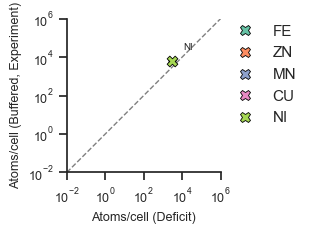

In [18]:

_meas_cnts = meas_buf_minimal['measured_M'].apply(
    lambda v: M_to_atoms(v, CELL_VOLUME_FL['Minimal'])
)
_meas_err_cnts = meas_buf_minimal['measured_std_M'].apply(
    lambda v: M_to_atoms(v, CELL_VOLUME_FL['Minimal'])
)

_deficit_min = M_to_atoms(deficit_minimal, CELL_VOLUME_FL['Minimal'])
_boo = _deficit_min['deficit_M'] > 0
_deficit_min = _deficit_min[_boo]


_common = sorted(
    set(_deficit_min.index) & set(_meas_cnts.dropna().index) & set(TARGET_METALS)
)

_rows = []
for el in _common:
    meas = float(_meas_cnts[el])
    meas_err = float(_meas_err_cnts[el])
    deficit_min = float(_deficit_min.loc[el, 'deficit_M'])
    deficit_err = float(_deficit_min.loc[el, 'deficit_M_err'])
    if meas <= 0 or np.isnan(meas):
        continue
    _rows.append({
        'Element': el,
        'x_count': deficit_min,
        'x_err_count': deficit_err,
        'y_count': meas,
        'y_err_count': meas_err,
    })

_plot_df_buf = pd.DataFrame(_rows)

_palette_buf = sns.color_palette("Set2", n_colors=len(_elements_buf))
_color_map_buf = dict(zip(_elements_buf, _palette_buf))

fig3, ax3 = plt.subplots(figsize=(4, 2.5))

_ref = np.logspace(-2, 7, 300)
ax3.plot(_ref, _ref, ls="--", color="gray", lw=1, zorder=0)

sns.scatterplot(
    data = _plot_df_buf,
    x="x_count",
    y="y_count",
    hue="Element",
    palette="Set2",
    marker="X",
    hue_order=_elements_buf,
    s=60,
    edgecolor="black",
    linewidth=0.6,
    ax=ax3,
    zorder=1,
)

for _, row in _plot_df_buf.iterrows():
    c = _color_map_buf[row["Element"]]
    ax3.errorbar(
        row["x_count"], row["y_count"],
        xerr=row['x_err_count'],
        yerr=row["y_err_count"],
        fmt="none",
        color='black',
        capsize=3,
        lw=0.8,
        zorder=-1,
        elinewidth=1,
    )

for _, row in _plot_df_buf.iterrows():
    ax3.annotate(
        row["Element"],
        xy=(row["x_count"], row["y_count"]),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=7,
    )


ax3.set_xscale("log")
ax3.set_yscale("log")
ax3.set_xlim(1e-2, 1e6)
ax3.set_ylim(1e-2, 1e6)

ax3.tick_params(axis='both', labelsize=9, labelfontfamily="sans-serif")
# make equal aspect ratio
plt.gca().set_aspect('equal', adjustable='box')

ax3.set_xlabel("Atoms/cell (Deficit)", fontsize=9)
ax3.set_ylabel("Atoms/cell (Buffered, Experiment)", fontsize=9)

ax3.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0, frameon=False)

sns.despine()
plt.rcParams['font.family'] = ['sans-serif']
plt.rcParams['font.sans-serif'] = ['Arial']
plt.tight_layout()
%matplotlib inline

plt.savefig('notebooks/cofactors/buffer_figures/deficit_vs_measured_matplotlib.svg')
plt.show()


In [28]:
minimal_count = 1/2*(M_to_atoms(est_competition_minimal_lb, CELL_VOLUME_FL['Minimal']) +
                 M_to_atoms(est_competition_minimal_ub, CELL_VOLUME_FL['Minimal']))
rich_count = 1/2*(M_to_atoms(est_competition_rich_lb, CELL_VOLUME_FL['Rich']) +
              M_to_atoms(est_competition_rich_ub, CELL_VOLUME_FL['Rich']))
minimal_count

MG    1.063761e+07
MN    9.393025e+04
FE    3.193166e+05
CO    6.471708e+02
NI    1.729481e+04
CU    1.864960e+00
ZN    4.111722e+04
Name: est_competition_M, dtype: float64

In [32]:
rich_count = 1/2*(M_to_atoms(est_competition_rich_lb, CELL_VOLUME_FL['Rich']) +
              M_to_atoms(est_competition_rich_ub, CELL_VOLUME_FL['Rich']))
rich_count = rich_count.reindex(index=order_index)
rich_count

Cu   NaN
Ni   NaN
Zn   NaN
Co   NaN
Fe   NaN
Mn   NaN
Mg   NaN
Name: est_competition_M, dtype: float64

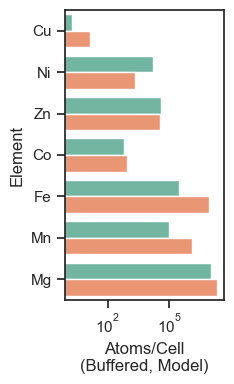

In [33]:
# bar plot of total buffered atoms/cell per metal for each condition
def _clean_ligand_name(name: str) -> str:
    renaming_dict = {"GLUTATHIONE[c]": "GSH", "CIT[c]": "Cit", "CYS[c]": "Cys", "HIS[c]": "His", "OXIDIZED-GLUTATHIONE[c]": "GSSG", "L-ASPARTATE[c]": "Asp", "L-GLUTAMATE[c]": "Glu", "LEU[c]": "Leu", "VAL[c]": "Val", "L-ALPHA-ALANINE[c]": "Ala",  "TRP[c]": "Trp", "ATP[c]": "ATP", "GLY[c]": "Gly", "MET[c]": "Met", "FE": "Fe", "ZN": "Zn", "MN": "Mn", "CU": "Cu", "MO": "Mo", "NI": "Ni", "V": "V", "CO": "Co", "MG": "Mg"}

    return renaming_dict.get(name, name)

minimal_count = 1/2*(M_to_atoms(est_competition_minimal_lb, CELL_VOLUME_FL['Minimal']) +
                 M_to_atoms(est_competition_minimal_ub, CELL_VOLUME_FL['Minimal']))
rich_count = 1/2*(M_to_atoms(est_competition_rich_lb, CELL_VOLUME_FL['Rich']) +
              M_to_atoms(est_competition_rich_ub, CELL_VOLUME_FL['Rich']))

minimal_count.index   = [_clean_ligand_name(i) for i in minimal_count.index]
rich_count.index = [_clean_ligand_name(i) for i in rich_count.index]
order_index = ['Cu', 'Ni', 'Zn', 'Co', 'Fe','Mn','Mg']
minimal_count = minimal_count.reindex(index=order_index)
rich_count = rich_count.reindex(index=order_index)
plot_df_total = pd.DataFrame({
    'Element': minimal_count.index,
    'Minimal': minimal_count.values,
    'Rich': rich_count.values,
}).melt(id_vars='Element', var_name='Medium', value_name='Buffered_Count')


plot_df_total['Element'] = pd.Categorical(plot_df_total['Element'], categories=order_index, ordered=True)
plot_df_total
fig4, ax4 = plt.subplots(figsize=(2.5, 4))

sns.barplot(
    data=plot_df_total,
    x='Buffered_Count',
    y='Element',
    hue='Medium',
    palette='Set2',
    orient='h',
    ax = ax4,
    legend=False,
)
ax4.set_xscale('log')
ax4.set_xlabel(f'Atoms/Cell\n(Buffered, Model)')
plt.rcParams['font.family'] = ['sans-serif']
plt.rcParams['font.sans-serif'] = ['Arial']
plt.tight_layout()

plt.savefig('notebooks/cofactors/buffer_figures/bar_total_buffer.svg')
plt.show()

In [93]:
plot_df_total

,Element,Medium,Buffered_Count
0,Cu,Minimal,1.864960e+00
1,Ni,Minimal,1.729481e+04
2,Zn,Minimal,4.111722e+04
3,Co,Minimal,6.471708e+02
4,Fe,Minimal,3.193166e+05
5,Mn,Minimal,9.393025e+04
6,Mg,Minimal,1.063761e+07
7,Cu,Rich,2.098658e+07
8,Ni,Rich,1.361347e+06
9,Zn,Rich,9.207340e+06


### Plot 6 – Per-ligand chelation contribution breakdown

In [21]:
%reset


Nothing done.


In [34]:
def per_ligand_chelation_breakdown(
    metals, free_metal, sim_buf,
    metal_to_buffer, buffer_to_metal,
):
    """
    Replicates the free_buf calculation from estimate_buffered_competition,
    then returns a per-ligand breakdown of chelated metal concentration (in M).
    1:1 stoichiometry only.

    Returns a list of dicts with keys:
        metal, ligand, contribution_M
    """
    free_metal_d = free_metal.to_dict()
    sim_buf_d = sim_buf.to_dict()

    # ── Step 1: free buffer concentrations ──
    free_buf = {}
    for buf in set(buffer_to_metal):
        total = sim_buf_d.get(buf, 0.0)
        B = 1.0
        for m, lb in buffer_to_metal.get(buf, {}).items():
            B += 10**lb * free_metal_d.get(m, 0.0)
        free_buf[buf] = total / B

    # ── Step 2: per-ligand breakdown ──
    rows = []
    for metal in metals:
        free_m = free_metal_d.get(metal, 0.0)
        for buf, lb in metal_to_buffer.get(metal, {}).items():
            contrib = free_m * 10**lb * free_buf.get(buf, 0.0)
            rows.append(dict(metal=metal, ligand=buf, contribution_M=contrib))
    return rows


# ── Build per-ligand tables for both conditions ──
for condition, free_metal, sim_buf in [
    ("Minimal", free_metal_minimal, sim_buf_minimal),
    ("Rich",    free_metal_rich,    sim_buf_rich),
]:
    rows = per_ligand_chelation_breakdown(
        ALL_METALS, free_metal, sim_buf,
        metal_to_buffer_ub, buffer_to_metal_ub,
    )
    df = pd.DataFrame(rows)
    df["contribution_uM"] = df["contribution_M"] * 1e6


# ── Build combined Altair dot plot ──
all_rows = []
for condition, free_metal, sim_buf in [
    ("Minimal", free_metal_minimal, sim_buf_minimal),
    ("Rich",    free_metal_rich,    sim_buf_rich),
]:
    rows = per_ligand_chelation_breakdown(
        ALL_METALS, free_metal, sim_buf,
        metal_to_buffer_ub, buffer_to_metal_ub,
    )
    for r in rows:
        r["condition"] = condition
    all_rows.extend(rows)

plot_df_ligand = (
    pl.DataFrame(all_rows)
    .with_columns(
        (pl.col("contribution_M") * 1e6).alias("contribution_uM")
    )
    .filter(pl.col("contribution_uM") > 0)
)

chart_per_ligand = (
    alt.Chart(plot_df_ligand.to_pandas())
    .mark_point(filled=True, size=80, opacity=0.85)
    .encode(
        x=alt.X("metal:N", title="Metal", axis=alt.Axis(labelAngle=0)),
        y=alt.Y(
            "contribution_uM:Q",
            title="Per-ligand chelated [M] (µM)",
            scale=alt.Scale(type="log"),
        ),
        color=alt.Color(
            "ligand:N",
            title="Ligand",
            scale=alt.Scale(scheme="tableau20"),
        ),
        tooltip=["metal", "ligand", alt.Tooltip("contribution_uM:Q", format=".3e")],
        facet=alt.Facet("condition:N", columns=2, title="Condition"),
    )
    .properties(width=320, height=260)
    .resolve_scale(y="shared")
    .properties(
        title=alt.TitleParams(
            "Per-ligand chelation contribution (Competition Model, upper bound)",
            anchor="middle",
        )
    )
)
# chart_per_ligand.save('notebooks/cofactors/buffer_figures/per_ligand_contribution.svg')
chart_per_ligand


alt.Chart(...)

# Fraction bound of metal:metabolite heatmap

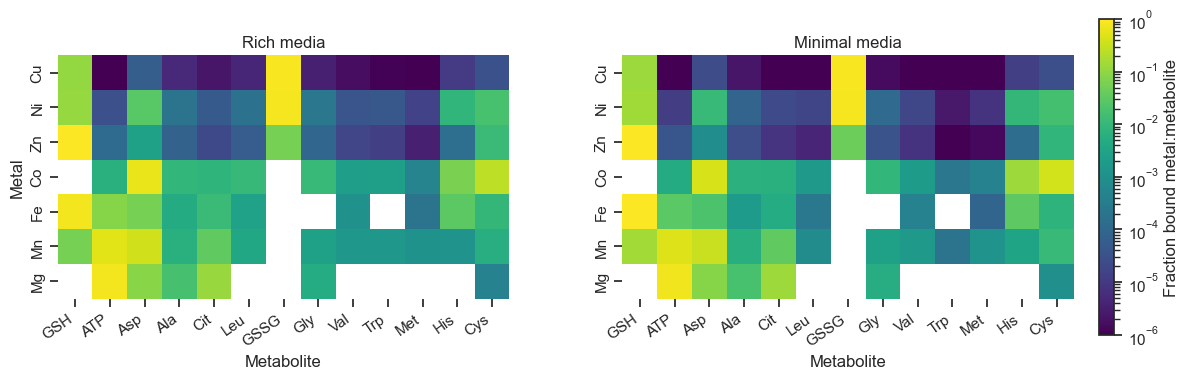

In [35]:
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogLocator, LogFormatterSciNotation, NullLocator, MultipleLocator
# Fraction-bound heatmap: per-metal fraction of CHELATED metal bound to each
# metabolite, computed with the competition model using the midpoint of the
# LB/UB logβ stability constants. Minimal vs. Rich media shown side-by-side.

# Midpoint logβ dicts: mean of UB and LB. With the current LB = stability - 1
# and UB = stability + 1, this collapses to the original `stability` values,
# but we compute it explicitly so the cell stays correct if those offsets
# are changed upstream.
metal_to_buffer_mid: dict[str, dict[str, float]] = {}
buffer_to_metal_mid: dict[str, dict[str, float]] = {}
for buf in set(buffer_to_metal_ub) | set(buffer_to_metal_lb):
    metals_ub = buffer_to_metal_ub.get(buf, {})
    metals_lb = buffer_to_metal_lb.get(buf, {})
    for m in set(metals_ub) & set(metals_lb):
        mid = 0.5 * (metals_ub[m] + metals_lb[m])
        buffer_to_metal_mid.setdefault(buf, {})[m] = mid
        metal_to_buffer_mid.setdefault(m, {})[buf] = mid


def _fraction_bound_per_metal(
    metals, free_metal, sim_buf,
    metal_to_buffer, buffer_to_metal,
) -> pd.DataFrame:
    """Wide (metals × buffers) DataFrame of f(M, L) = contribution(M, L) /
    Σ_L contribution(M, L) — the share of each metal's chelated pool
    contributed by each ligand. Missing pairs are 0.0; metals with no
    chelation are filled with 0.0."""
    rows = per_ligand_chelation_breakdown(
        metals, free_metal, sim_buf, metal_to_buffer, buffer_to_metal,
    )
    df = (
        pd.DataFrame(rows)
        .pivot(index="metal", columns="ligand", values="contribution_M")
        .reindex(index=list(metals), columns=ALL_BUFFERS)
        .fillna(0.0)
    )
    denom = df.sum(axis=1).replace(0.0, np.nan)
    return df.div(denom, axis=0).fillna(0.0)


frac_bound_minimal = _fraction_bound_per_metal(
    ALL_METALS, free_metal_minimal, sim_buf_minimal,
    metal_to_buffer_mid, buffer_to_metal_mid,
)
frac_bound_rich = _fraction_bound_per_metal(
    ALL_METALS, free_metal_rich, sim_buf_rich,
    metal_to_buffer_mid, buffer_to_metal_mid,
)


def _clean_ligand_name(name: str) -> str:
    renaming_dict = {"GLUTATHIONE[c]": "GSH", "CIT[c]": "Cit", "CYS[c]": "Cys", "HIS[c]": "His", "OXIDIZED-GLUTATHIONE[c]": "GSSG", "L-ASPARTATE[c]": "Asp", "L-GLUTAMATE[c]": "Glu", "LEU[c]": "Leu", "VAL[c]": "Val", "L-ALPHA-ALANINE[c]": "Ala",  "TRP[c]": "Trp", "ATP[c]": "ATP", "GLY[c]": "Gly", "MET[c]": "Met", "FE": "Fe", "ZN": "Zn", "MN": "Mn", "CU": "Cu", "MO": "Mo", "NI": "Ni", "V": "V", "CO": "Co", "MG": "Mg"}

    return renaming_dict.get(name, name)


frac_bound_minimal.columns = [_clean_ligand_name(c) for c in frac_bound_minimal.columns]
frac_bound_minimal.index   = [_clean_ligand_name(i) for i in frac_bound_minimal.index]
frac_bound_rich.columns    = [_clean_ligand_name(c) for c in frac_bound_rich.columns]
frac_bound_rich.index     = [_clean_ligand_name(i) for i in frac_bound_rich.index]

frac_bound_minimal_log = frac_bound_minimal.replace(0.0, np.nan)
positive = frac_bound_minimal_log.to_numpy()
positive = positive[np.isfinite(positive)]
vmin = max(positive.min(), 1e-6)
vmax = 1.0

n_metals  = len(ALL_METALS)
n_ligands = len(ALL_BUFFERS)

fig, axes = plt.subplots(
    1, 2,
    figsize=(max(7.0, 0.55 * n_ligands) * 2 + 1.5, 0.55 * n_metals + 2.0),
    sharey=False,
    gridspec_kw={"wspace": 0.25},
)
cmap = plt.get_cmap("viridis").copy()
for ax, df, title in zip(
    axes,
    [frac_bound_rich, frac_bound_minimal],
    ["Rich media", "Minimal media"],
):
    order_index = ['Cu', 'Ni', 'Zn', 'Co', 'Fe','Mn','Mg']
    order_col = ['GSH', 'ATP', 'Asp', 'Ala', 'Cit', 'Leu', 'GSSG', 'Gly', 'Val', 'Trp', 'Met', 'His', 'Cys']
    df = df.reindex(index=order_index, columns=order_col)
    sns.heatmap(
        data=df,
        cmap=cmap,
        norm=LogNorm(vmin=vmin, vmax=vmax),
        annot=False,
        fmt=".2f",
        square=True,
        cbar=False,
        ax=ax,
        # linewidths=0.5,
        # linecolor="white",
        annot_kws={"fontsize": 8},
    )
    ax.set_title(title)
    ax.set_xlabel("Metabolite")
    ax.set_ylabel("Metal" if ax is axes[0] else "")
    ax.tick_params(axis="x", rotation=35)
    for lbl in ax.get_xticklabels():
        lbl.set_ha("right")



cbar = fig.colorbar(
    axes[1].collections[0], ax=axes, location="right",
    shrink=0.7, pad=0.02,
)
cbar.set_label("Fraction bound metal:metabolite")

plt.savefig(
    "notebooks/cofactors/buffer_figures/fraction_bound_heatmap.svg",
    dpi=300, transparent=True, bbox_inches="tight",
)
plt.show()

### Plot 2 – Simplified model: estimated buffered [Metal] vs. M-M deficit

In [ ]:
plot_df_simp = build_plot_df(
    est_simplified_minimal_lb, est_simplified_minimal_ub,
    est_simplified_rich_lb,    est_simplified_rich_ub,
    deficit_minimal, deficit_rich,
)

df = pl.from_pandas(plot_df_simp).with_columns([
    (pl.col("est_buf_center_M") * 1e6).alias("x_uM"),
    (pl.col("est_buf_lb_M")     * 1e6).alias("x_lb_uM"),
    (pl.col("est_buf_ub_M")     * 1e6).alias("x_ub_uM"),
    (pl.col("deficit_M")        * 1e6).alias("y_uM"),
    (pl.col("deficit_M_err")    * 1e6).alias("y_err_uM"),
])

DOMAIN_MIN = 1e-7   # just below your domain floor of 1e-6

df = df.with_columns([
    pl.max_horizontal(
        pl.col("y_uM") - pl.col("y_err_uM"),
        pl.lit(DOMAIN_MIN)
    ).alias("y_lo_uM"),
    (pl.col("y_uM") + pl.col("y_err_uM")).alias("y_hi_uM"),
])

base = alt.Chart(df).encode(
)
x_scale = alt.Scale(type="log", domain=[1e-6, 1e6])
y_scale = alt.Scale(type="log", domain=[1e-6, 1e6])

_ax_x = alt.Axis(labelExpr=_log_label_unicode, title="Modeled Buffered [Metal] [µmol/L]")
_ax_y = alt.Axis(labelExpr=_log_label_unicode, title="Estimated Deficit [µmol/L]")

ref_line = alt.Chart(ref_df).mark_line(strokeDash=[4,4], color="gray").encode(
    x=alt.X("v:Q", scale=x_scale, axis=_ax_x),
    y=alt.Y("v:Q", scale=y_scale, axis=_ax_y),
)
x_bars = base.mark_errorbar(ticks=True).encode(
    x=alt.X("x_lb_uM:Q", scale=x_scale, title=""),
    x2="x_ub_uM:Q",
    y=alt.Y("y_uM:Q", scale=y_scale),
    color="Medium:N",
)
y_bars = base.mark_errorbar(ticks=True, clip=True).encode(
    x=alt.X("x_uM:Q"),
    y=alt.Y("y_lo_uM:Q",  scale=y_scale, title=""),   # explicit log scale + clamped lower
    y2=alt.Y2("y_hi_uM:Q"),
    color="Medium:N",
)
points = base.mark_point(filled=True, size=150, stroke='black', strokeWidth=1).encode(
    x=alt.X("x_uM:Q", scale=x_scale, axis=_ax_x),
    y=alt.Y("y_uM:Q", scale=y_scale, axis=_ax_y),
    color=alt.Color("Medium:N",
        scale=alt.Scale(domain=["Minimal","Rich"], range=["steelblue","tomato"])),
    shape=alt.Shape("Medium:N",
        scale=alt.Scale(domain=["Minimal","Rich"], range=["circle","diamond"])),
)
# 5. Text labels
labels = base.mark_text(dx=15, dy=-15, fontSize=12).encode(
    x=alt.X("x_uM:Q", scale=alt.Scale(type="log")),
    y=alt.Y("y_uM:Q", scale=alt.Scale(type="log")),
    text="Element:N",
)
chart = (ref_line + x_bars + y_bars + points + labels).properties(
    width=600, height=480,
    title="Buffered Metal Concentration vs. Deficit Fig1C – Simplified Model"
).configure_axis(gridColor='#f3f6fa')
# chart.save('notebooks/cofactors/buffer_figures/buffered_metal_vs_deficit_simplified.svg')
chart

### Plot 3 – Overlay: competition vs. simplified, with shift arrows

In [ ]:
def prep_model_df(plot_df_pd, model_label: str) -> pl.DataFrame:
    return (
        pl.from_pandas(plot_df_pd)
        .with_columns([
            (pl.col("est_buf_center_M") * 1e6).alias("x_uM"),
            (pl.col("deficit_M")        * 1e6).alias("y_uM"),
            pl.lit(model_label).alias("model"),
        ])
        .filter((pl.col("x_uM") > 0) & (pl.col("y_uM") > 0))
    )

df_simp = prep_model_df(plot_df_simp, "simplified")
df_comp = prep_model_df(plot_df_comp, "competition")

df_simp = df_simp.with_columns(
    pl.concat_str([pl.col("Medium"), pl.lit(" (simplified)")]).alias("medium_model")
)
df_comp = df_comp.with_columns(
    pl.concat_str([pl.col("Medium"), pl.lit(" (competition)")]).alias("medium_model")
)

# ── Scales for the four-way legend ───────────────────────────────────────────
DOMAIN = [
    "Minimal (simplified)", "Minimal (competition)",
    "Rich (simplified)",    "Rich (competition)",
]
COLOR_RANGE = ["steelblue", "steelblue", "tomato", "tomato"]
SHAPE_RANGE = ["circle",    "circle",    "diamond", "diamond"]
OPACITY_RANGE = [0.4, 1.0, 0.4, 1.0]   # simplified = faded, competition = solid

color_scale4 = alt.Scale(domain=DOMAIN, range=COLOR_RANGE)
shape_scale4 = alt.Scale(domain=DOMAIN, range=SHAPE_RANGE)

_ax_x = alt.Axis(labelExpr=_log_label_unicode, title="Modeled Buffered [Metal] [µmol/L]")
_ax_y = alt.Axis(labelExpr=_log_label_unicode, title="Estimated Deficit [µmol/L]")

legend_cfg = alt.Legend(title="Medium / Model")
# Arrow table: one row per (Medium, Element) pair
df_arrows = (
    df_simp.join(df_comp, on=["Medium", "Element"], suffix="_comp")
    .filter(
        (pl.col("x_uM_comp") > 0) & (pl.col("y_uM_comp") > 0) &
        ((pl.col("x_uM_comp") - pl.col("x_uM")).abs() +
         (pl.col("y_uM_comp") - pl.col("y_uM")).abs() > 1e-10)
    )
)

# Compute arrowhead angle in log10 space — in Vega 0°=up, clockwise positive
x0 = df_arrows["x_uM"].to_numpy()
y0 = df_arrows["y_uM"].to_numpy()
x1 = df_arrows["x_uM_comp"].to_numpy()
y1 = df_arrows["y_uM_comp"].to_numpy()
math_angle = np.degrees(np.arctan2(np.log10(y1/y0), np.log10(x1/x0)))
vega_angle  = 90 - math_angle   # convert: math 0°=right → Vega 0°=up

df_arrows = df_arrows.with_columns(
    pl.Series("arrow_angle_deg", vega_angle)
)

x_scale = alt.Scale(type="log", domain=[1e-6, 1e6])
y_scale = alt.Scale(type="log", domain=[1e-6, 1e6])
color_scale = alt.Scale(
    domain=["Minimal","Rich"],
    range=["steelblue","tomato"]
)
shape_scale = alt.Scale(
    domain=["Minimal","Rich"],
    range=["circle","diamond"]
)

# 1. y = x reference
ref_line = (
    alt.Chart(pl.DataFrame({"v": [1e-6, 1e6]}))
    .mark_line(strokeDash=[4,4], color="gray")
    .encode(
        x=alt.X("v:Q", scale=x_scale, axis=_ax_x),
        y=alt.Y("v:Q", scale=y_scale, axis=_ax_y),
    )
)

# 2. Simplified points — semi-transparent
simp_pts = (
    alt.Chart(df_simp)
    .mark_point(filled=True, size=150, stroke="black", strokeWidth=1)
    .encode(
        x=alt.X("x_uM:Q", scale=x_scale, title="Modeled Buffered [Metal] [µmol/L]"),
        y=alt.Y("y_uM:Q", scale=y_scale, title="Estimated Deficit [µmol/L]"),
        color=alt.Color("medium_model:N", scale=color_scale4, legend=legend_cfg),
        shape=alt.Shape("medium_model:N", scale=shape_scale4, legend=legend_cfg),
        opacity=alt.OpacityValue(0.45),
    )
)


# 3. Competition points — opaque, with labels
comp_pts = (
    alt.Chart(df_comp)
    .mark_point(filled=True, size=150, stroke="black", strokeWidth=1)
    .encode(
        x=alt.X("x_uM:Q", scale=x_scale),
        y=alt.Y("y_uM:Q", scale=y_scale),
        color=alt.Color("medium_model:N", scale=color_scale4, legend=legend_cfg),
        shape=alt.Shape("medium_model:N", scale=shape_scale4, legend=legend_cfg),
        opacity=alt.OpacityValue(1.0),
    )
)

comp_labels = (
    alt.Chart(df_comp)
    .mark_text(dx=8, dy=-8, fontSize=11)
    .encode(
        x=alt.X("x_uM:Q", scale=x_scale),
        y=alt.Y("y_uM:Q", scale=y_scale),
        text="Element:N",
    )
)

# 4a. Arrow lines (simplified → competition)
arrow_lines = (
    alt.Chart(df_arrows)
    .mark_rule(color="gray", opacity=0.6, strokeWidth=1.2)
    .encode(
        x=alt.X( "x_uM:Q",      scale=x_scale),
        y=alt.Y( "y_uM:Q",      scale=y_scale),
        x2=alt.X2("x_uM_comp:Q"),
        y2=alt.Y2("y_uM_comp:Q"),
    )
)

# 4b. Arrowheads at the tip (competition end)
arrow_heads = (
    alt.Chart(df_arrows)
    .mark_point(shape="triangle", filled=True, size=20,
                color="darkgray", opacity=0.8)
    .encode(
        x=alt.X("x_uM_comp:Q", scale=x_scale),
        y=alt.Y("y_uM_comp:Q", scale=y_scale),
        angle=alt.Angle("arrow_angle_deg:Q",
                        scale=alt.Scale(domain=[0,360], range=[0,360])),
    )
)

chart3 = (
    ref_line +  simp_pts +  comp_pts + arrow_lines + arrow_heads + comp_labels
).properties(
    width=600, height=480,
    title="Overlay: Competition vs. Simplified Buffering Models"
).configure_axis(gridColor="#f3f6fa")
# chart3.save("notebooks/cofactors/buffer_figures/two_models_comparison.svg")
chart3

### Plot 4 – Categorical scatter: Deficit Figure 1C vs. modeled vs. measured buffered concentration (Minimal Media)

Each element on the x-axis has three offset points:
- **Deficit (Fig 1C)** – ICP-MS total − simulation ± propagated error
- **Modeled Buffered** – competition-model mid-point ± half the lb/ub range
- **Measured Buffered** – experimentally measured ± std


In [36]:
DOMAIN_MIN = 1e-7
elements = results_minimal.index.tolist()

bar_df = pd.DataFrame({
    'element':         elements,
    'deficit_uM':      results_minimal['deficit_M']       * 1e6,
    'deficit_err_uM':  results_minimal['deficit_M_err']   * 1e6,
    'model_uM_lb':        est_competition_minimal_lb.reindex(elements) * 1e6,
    'model_uM_ub':        est_competition_minimal_ub.reindex(elements) * 1e6,
    'measured_uM':     meas_buf_minimal['measured_M'].reindex(elements) * 1e6,
    'measured_err_uM': meas_buf_minimal['measured_std_M'].reindex(elements) * 1e6,
}).set_index("element")


df_wide = pl.from_pandas(bar_df.reset_index()).with_columns([
    (0.5 * (pl.col("model_uM_lb") + pl.col("model_uM_ub"))).alias("model_mid_uM"),
    (0.5 * (pl.col("model_uM_ub") - pl.col("model_uM_lb")).abs()).alias("model_err_uM"),
])

_series_labels = {
    "Deficit (Fig 1C)":  ("deficit_uM",   "deficit_err_uM"),
    "Modeled Buffered":  ("model_mid_uM", "model_err_uM"),
    "Measured Buffered": ("measured_uM",  "measured_err_uM"),
}

df_long = pl.concat([
    df_wide.select([
        pl.col("element"),
        pl.col(y_col).alias("y_uM"),
        pl.col(e_col).fill_null(0).alias("y_err_uM"),
        pl.lit(label).alias("series"),
    ])
    for label, (y_col, e_col) in _series_labels.items()
]).filter(
    pl.col("y_uM").is_not_null()
).filter(
    # Keep row if it's NOT (deficit series AND negative value)
    ~((pl.col("series") == "Deficit (Fig 1C)") & (pl.col("y_uM") < 0))
).with_columns([
    pl.max_horizontal(
        pl.col("y_uM") - pl.col("y_err_uM"),
        pl.lit(DOMAIN_MIN)
    ).alias("y_lo_uM"),
    (pl.col("y_uM") + pl.col("y_err_uM")).alias("y_hi_uM"),
])

elements_ordered = bar_df.index.tolist()
_series_domain   = list(_series_labels.keys())

y_scale   = alt.Scale(type="log", domain=[1e-6, 1e6])
col_scale = alt.Scale(domain=_series_domain, range=["steelblue", "tomato", "seagreen"])
shp_scale = alt.Scale(domain=_series_domain, range=["circle", "diamond", "square"])
_legend   = alt.Legend(title="Method")

x_enc      = alt.X("element:N", sort=elements_ordered, title="Metal Element",
                   axis=alt.Axis(labelAngle=0))
xoff_enc   = alt.XOffset("series:N", sort=_series_domain)
color_enc  = alt.Color("series:N", scale=col_scale, legend=_legend)

base = alt.Chart(df_long)

points = (
    base.mark_point(filled=True, size=90, stroke="black", strokeWidth=1)
    .encode(
        x=x_enc,
        xOffset=xoff_enc,
        y=alt.Y("y_uM:Q", scale=y_scale, title="Concentration [µmol/L]",
                axis=alt.Axis(labelExpr=_log_label_unicode)),
        color=color_enc,
        shape=alt.Shape("series:N", scale=shp_scale, legend=_legend),
    )
)

# ── Error bar body (rule) ─────────────────────────────────────────────────────
err_rule = (
    base.mark_rule(strokeWidth=1.5, clip=True)
    .encode(
        x=x_enc,
        xOffset=xoff_enc,                               # ← works on mark_rule
        y=alt.Y("y_lo_uM:Q", scale=y_scale),
        y2=alt.Y2("y_hi_uM:Q"),
        color=color_enc,
    )
)

# ── Error bar caps (tick) ─────────────────────────────────────────────────────
err_cap_lo = (
    base.mark_tick(width=6, thickness=1.5, clip=True)
    .encode(x=x_enc, xOffset=xoff_enc,
            y=alt.Y("y_lo_uM:Q", scale=y_scale), color=color_enc)
)
err_cap_hi = (
    base.mark_tick(width=6, thickness=1.5, clip=True)
    .encode(x=x_enc, xOffset=xoff_enc,
            y=alt.Y("y_hi_uM:Q", scale=y_scale), color=color_enc)
)

chart8 = (err_rule + err_cap_lo + err_cap_hi + points).properties(
    width=700, height=450,
    title="Deficit Fig 1C, Measured, and Modeled Buffer – Categorical Scatter (Minimal Media)"
).configure_axis(gridColor="#f3f6fa")

# chart8.save("notebooks/cofactors/buffer_figures/categorical_scatter_minimal.svg")
chart8

alt.LayerChart(...)

### Plot 5 – NI: Minimal vs Rich (horizontal categorical scatter, atoms/cell)

Matplotlib figure: modeled (competition), deficit (Fig 1C), and measured series with uncertainties. Rich media has no measured buffered points. Style defaults to `dark_background` (set `plt.style.use("default")` for a light figure).


In [ ]:
from matplotlib import pyplot as plt
%matplotlib inline
plt.style.use("default")

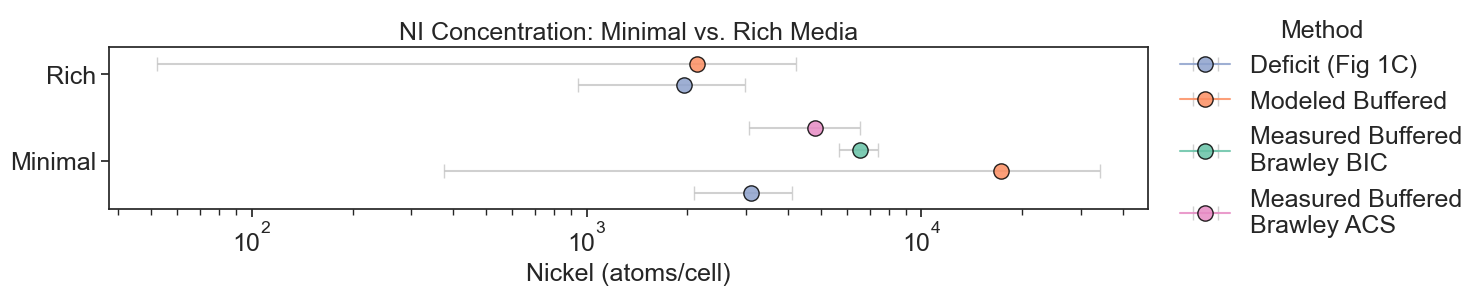

In [140]:
# Plot 5— NI: horizontal categorical scatter (Minimal vs Rich), atoms/cell [matplotlib]
# Concentrations in µM → atoms/cell via M_to_atoms(c_M, vol_fL)
_NI_UM = {
    "Minimal": {
        "Deficit (Fig 1C)": (
            float(deficit_minimal.loc["NI", "deficit_M"]) * 1e6,
            float(deficit_minimal.loc["NI", "deficit_M_err"]) * 1e6,
        ),
        "Modeled Buffered": (
            0.5 * (float(est_competition_minimal_lb["NI"]) + float(est_competition_minimal_ub["NI"])) * 1e6,
            0.5 * abs(float(est_competition_minimal_ub["NI"]) - float(est_competition_minimal_lb["NI"])) * 1e6,
        ),
        f"Measured Buffered\nBrawley BIC": (
            float(meas_buf_minimal.loc["NI", "measured_M"]) * 1e6,
            float(meas_buf_minimal.loc["NI", "measured_std_M"]) * 1e6,
        ),
        f"Measured Buffered\nBrawley ACS": (
            11 / 2,
            4 / 2, # divide by 2 to account for 50% cytosolic assumption
        ),
    },
    "Rich": {
        "Deficit (Fig 1C)": (
            float(deficit_rich.loc["NI", "deficit_M"]) * 1e6,
            float(deficit_rich.loc["NI", "deficit_M_err"]) * 1e6,
        ),
        "Modeled Buffered": (
            0.5 * (float(est_competition_rich_lb["NI"]) + float(est_competition_rich_ub["NI"])) * 1e6,
            0.5 * abs(float(est_competition_rich_ub["NI"]) - float(est_competition_rich_lb["NI"])) * 1e6,
        ),
    },
}

_rows = []
for medium, by_series in _NI_UM.items():
    vol_fL = CELL_VOLUME_FL[medium]
    for series_name, (y_um, err_um) in by_series.items():
        c_M = y_um * 1e-6
        e_M = err_um * 1e-6
        _rows.append(
            {
                "medium": medium,
                "series": series_name,
                "atoms": M_to_atoms(c_M, vol_fL),
                "err_atoms": M_to_atoms(e_M, vol_fL),
            }
        )

df_ni_plot = pd.DataFrame(_rows).query("atoms > 0")

series_order = [
    "Deficit (Fig 1C)",
    "Modeled Buffered",
    f"Measured Buffered\nBrawley BIC",
    f"Measured Buffered\nBrawley ACS",
]
medium_order = ["Minimal", "Rich"]
palette = {
    "Deficit (Fig 1C)": "#8da1cc",
    "Modeled Buffered": "#fc8e62",
    f"Measured Buffered\nBrawley BIC": "#66c2a6",
    f"Measured Buffered\nBrawley ACS": "#e78bc4",
}


h_strip = 3
offsets = {s: 0.3 + (i * (h_strip - 1) / 5) for i, s in enumerate(series_order)}
fig, ax = plt.subplots(figsize=(15, h_strip))

for j, medium in enumerate(medium_order):
    if medium == "Minimal":
        marker='X'
    else:
        marker='o'
    for series_name in series_order:
        sel = df_ni_plot[
            (df_ni_plot["medium"] == medium) & (df_ni_plot["series"] == series_name)
        ]
        if sel.empty:
            continue
        val = float(sel["atoms"].iloc[0])
        err = float(sel["err_atoms"].iloc[0])
        y_pos = (j * (h_strip - 1)) + offsets[series_name]
        ax.errorbar(
            val,
            y_pos,
            xerr=err,
            color=palette[series_name],
            alpha=0.85,
            capsize=5,
            capthick=1.5,
            linewidth=1.5,
            ecolor="#c8c8c8",
            marker="o",
            markersize=11,
            markeredgecolor="black",
            markeredgewidth=1,
            label=series_name if j == 0 else "_nolegend_",
        )

ax.set_xscale("log")
ax.set_yticks([0.9, 2.5])
ax.set_ylim(0.0, 3)
ax.set_yticklabels(medium_order, fontsize=18)
ax.set_xlabel("Nickel (atoms/cell)", fontsize=18)
ax.set_ylabel("")
ax.set_title("NI Concentration: Minimal vs. Rich Media", fontsize=18)
ax.tick_params(axis="both", labelsize=18)
ax.legend(
    title="Method",
    frameon=False,
    bbox_to_anchor=(1.01, 0.5),
    loc="center left",
    fontsize=18,
    title_fontsize=18,
)
fig.tight_layout()
# fig.savefig(
#     "notebooks/cofactors/buffer_figures/NI_bar_atoms_per_cell.svg",
#     bbox_inches="tight",
#     facecolor=fig.get_facecolor(),
# )
plt.show()

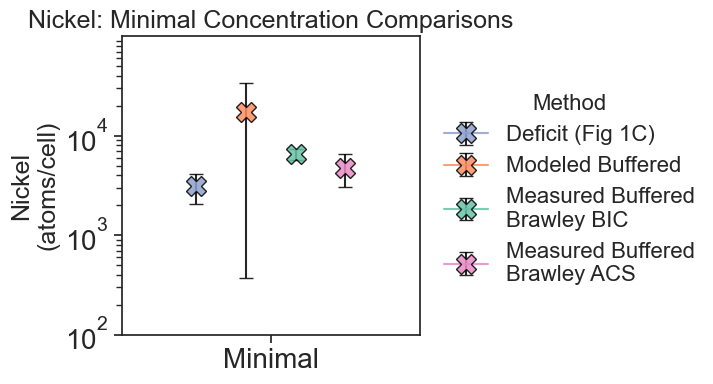

In [197]:
medium_order = ["Minimal"]
w_strip = 3
offsets = {s: 0.75 + (i * (w_strip - 2) / 2) for i, s in enumerate(series_order)}
fig, ax = plt.subplots(figsize=(6, 4))
for j, medium in enumerate(medium_order):
    for series_name in series_order:
        sel = df_ni_plot[
            (df_ni_plot["medium"] == medium) & (df_ni_plot["series"] == series_name)
        ]
        if sel.empty:
            continue
        val = float(sel["atoms"].iloc[0])
        err = float(sel["err_atoms"].iloc[0])
        x_pos = (j * (w_strip - 1)) + offsets[series_name]
        ax.errorbar(
            x_pos,
            val,
            yerr=err,
            color=palette[series_name],
            alpha=0.85,
            capsize=5,
            capthick=1.5,
            linewidth=1.5,
            # ecolor="#c8c8c8",
            ecolor = 'black',
            marker="X",
            markersize=15,
            markeredgecolor="black",
            markeredgewidth=1,
            label=series_name if j == 0 else "_nolegend_",
        )

ax.set_yscale("log")          # log on the value axis (now y)
ax.set_xticks([1.5])
ax.set_xlim(0.0, 3)
ax.set_ylim(1E2, 1E5)
ax.set_yticks([1E2, 1E3, 1E4])
ax.set_xticklabels(medium_order, fontsize=18)
ax.tick_params(axis="both", labelsize=20)
ax.set_ylabel(f"Nickel\n(atoms/cell)", fontsize=18)
ax.set_title("Nickel: Minimal Concentration Comparisons", fontsize=18)
ax.set_xlabel("")

ax.legend(
    title="Method",
    frameon=False,
    bbox_to_anchor=(1.5, 0.1),   # move legend above the square plot
    loc="lower center",
    fontsize=16,
    title_fontsize=16,
)
# plt.gca().set_aspect('equal', adjustable='box')
ax.set_box_aspect(1)
fig.tight_layout()
fig.savefig(
    "notebooks/cofactors/buffer_figures/NI_scatter_atoms_per_cell.svg",
    bbox_inches="tight",
    facecolor=fig.get_facecolor(),
)
plt.show()

In [198]:
df_ni_plot_min

,medium,series,atoms,err_atoms,element
0,Minimal,Deficit (Fig 1C),3095.994897,1007.873955,Ni
1,Minimal,Modeled Buffered,17294.814541,16918.385560,Ni
2,Minimal,Measured Buffered\nBrawley BIC,6548.310254,873.108034,Ni
3,Minimal,Measured Buffered\nBrawley ACS,4802.094186,1746.216068,Ni


/var/folders/s9/gn2yly0s7rzgcc2xyvt7nsxm0000gr/T/ipykernel_45797/2944310614.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ni_plot_min['element'] = 'Ni'


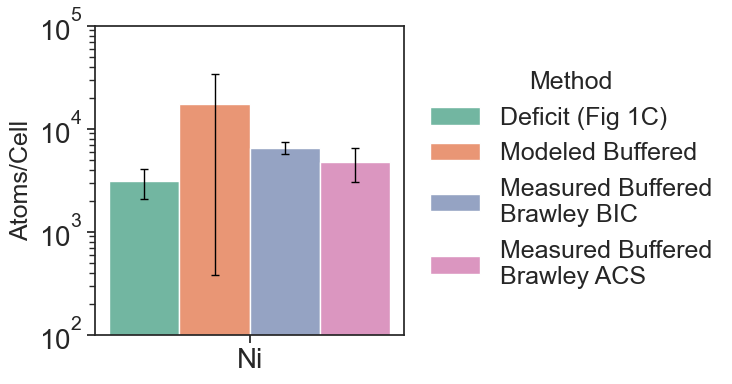

In [212]:
df_ni_plot_min = df_ni_plot[df_ni_plot["medium"] == "Minimal"]
df_ni_plot_min['element'] = 'Ni'

fig5, ax5 = plt.subplots(figsize=(8, 4))

sns.barplot(
    data=df_ni_plot_min,
    x='element',
    y='atoms',
    palette='Set2',
    hue='series',
    ax = ax5,
    legend=True,
)

x_coords = [p.get_x() + 0.5 * p.get_width() for p in ax5.patches][:4]
y_coords = [p.get_height() for p in ax5.patches][:4]

ax5.errorbar(
    x_coords, y_coords,
    yerr=df_ni_plot_min["err_atoms"],
    fmt="none",
    color='black',
    capsize=3,
    lw=0.8,
    zorder=2,
    elinewidth=1,
)
ax5.set_yscale('log')
ax5.set_ylim([1E2, 1E5])
# ax5.set_xticklabels(ax5.get_xticklabels(), rotation=45, ha="right")
ax5.set_ylabel(f'Atoms/Cell', fontsize=18)
ax5.set_xlabel('')
ax5.set_yticks([1E2, 1E3, 1E4, 1E5])
ax5.legend(
    title="Method",
    frameon=False,
    bbox_to_anchor=(1.01, 0.5),
    loc="center left",
    fontsize=18,
    title_fontsize=18,
)
ax5.tick_params(axis="both", labelsize=20)
ax5.set_box_aspect(1)
plt.rcParams['font.family'] = ['sans-serif']
plt.rcParams['font.sans-serif'] = ['Arial']
plt.tight_layout()

plt.savefig('notebooks/cofactors/buffer_figures/NI_bar_atoms_per_cell.svg')
plt.show()

In [ ]:
ax3.errorbar(
        row["x_count"], row["y_count"],
        xerr=row['x_err_count'],
        yerr=row["y_err_count"],
        fmt="none",
        color='black',
        capsize=3,
        lw=0.8,
        zorder=-1,
        elinewidth=1,
    )

### Plot 6 – Categorical scatter for NI, CO, Zn, MG: modeled, deficit (Fig 1C), and measured across Minimal and Rich media

In [ ]:
# ── Plot 6: matplotlib horizontal categorical scatter (same theme as Plot 10), NI / CO / ZN ──
from matplotlib import pyplot as plt

metals_plot = ["NI", "CO", "ZN", "MG"]

_rows_p11: list[dict] = []
for el in metals_plot:
    # Compile series for modeled and defcit for both conditions
    for medium in ["Minimal", "Rich"]:
        vol = CELL_VOLUME_FL[medium]
        deficit = deficit_minimal if medium == "Minimal" else deficit_rich
        est_lb = est_competition_minimal_lb if medium == "Minimal" else est_competition_rich_lb
        est_ub = est_competition_minimal_ub if medium == "Minimal" else est_competition_rich_ub

        try:
            deficit_M = float(deficit.loc[el, "deficit_M"])
            deficit_err = float(deficit.loc[el, "deficit_M_err"])
            _rows_p11.append({
                "element": el,
                "medium": medium,
                "series": "Deficit (Fig 1C)",
                "y_uM": M_to_atoms(deficit_M, vol),
                "y_err_uM": M_to_atoms(deficit_err, vol),
            })
        except: pass

        est_mean = 0.5 * (float(est_lb[el]) + float(est_ub[el]))
        est_err = 0.5 * abs(float(est_ub[el]) - float(est_lb[el]))
        _rows_p11.append({
            "element": el,
            "medium": medium,
            "series": "Modeled Buffered",
            "y_uM": M_to_atoms(est_mean, vol),
            "y_err_uM": M_to_atoms(est_err, vol),
        })

    # Add measured buffer concentration from Brawley
    # Only available for minimal media
    vol_m = CELL_VOLUME_FL["Minimal"]
    measured_M = meas_buf_minimal.loc[el, "measured_M"]
    measured_std = meas_buf_minimal.loc[el, "measured_std_M"]
    if pd.notna(measured_M) and pd.notna(measured_std):
        _rows_p11.append({
            "element": el,
            "medium": "Minimal",
            "series": "Measured Buffered - Brawley BIC",
            "y_uM": M_to_atoms(float(measured_M), vol_m),
            "y_err_uM": M_to_atoms(float(measured_std), vol_m),
        })

    # if NI, add one more minimal measurement from Brawley ACS paper
    # (11 ± 4 uM/cell → convert to atoms for plotting)
    if el == "NI":
        _rows_p11.append({
            "element": el,
            "medium": "Minimal",
            "series": "Measured Buffered - Brawley ACS",
            "y_uM": M_to_atoms((11 / 2) * 1e-6, vol_m),
            "y_err_uM": M_to_atoms((4 / 2) * 1e-6, vol_m),
        })

df_p11_ = pd.DataFrame(_rows_p11)

series_order = ["Deficit (Fig 1C)", "Modeled Buffered",
                "Measured Buffered - Brawley BIC", "Measured Buffered - Brawley ACS"]
medium_order = ["Minimal", "Rich"]

palette_series = {
    "Deficit (Fig 1C)": "#8da1cc",
    "Modeled Buffered": "#fc8e62",
    "Measured Buffered - Brawley BIC": "#66c2a6",
    "Measured Buffered - Brawley ACS": "#e78bc4",
}
markers_series = {
    "Minimal": "o",
    "Rich": "o",
}

h = 3
offsets = {s: 0.3 + (i * (h - 1) / 5) for i, s in enumerate(series_order)}

xlabel_map = {
    "NI": "Nickel \n (atoms/cell)",
    "CO": "Cobalt \n (atoms/cell)",
    "ZN": "Zinc \n (atoms/cell)",
    "MG": "Magnesium \n (atoms/cell)",
}


def _draw_metal_panels(metals, axes, xlim=None):
    """Populate a pre-created axes array with one panel per metal."""
    for ax_idx, el in enumerate(metals):
        ax = axes[ax_idx]
        sub = df_p11_[df_p11_["element"] == el]
        y_ticks = []
        for j, medium in enumerate(medium_order):
            medium_ticks = []
            for series_name in series_order:
                row = sub[(sub["medium"] == medium) & (sub["series"] == series_name)]
                if row.empty:
                    continue

                val = row["y_uM"].values[0]
                err = row["y_err_uM"].values[0]
                y_pos = (j * (h - 0.5 * 2)) + offsets[series_name]
                medium_ticks.append(y_pos)
                ax.errorbar(
                    x=val,
                    y=y_pos,
                    xerr=err,
                    fmt=markers_series[medium],
                    alpha=0.7,
                    color=palette_series[series_name],
                    capsize=5,
                    capthick=1.5,
                    linewidth=1.5,
                    markersize=11,
                    markeredgecolor="black",
                    markeredgewidth=1,
                    label=series_name if (j == 0 and ax_idx == 0) else "_nolegend_",
                )
            y_ticks.append(np.mean(medium_ticks))

        ax.set_xscale("log")
        ax.set_yticks(y_ticks)
        ax.set_ylim(0.0, 3)
        if xlim is not None:
            ax.set_xlim(*xlim)
        ax.set_yticklabels(medium_order, fontsize=18)
        ax.set_ylabel(xlabel_map[el], fontsize=18)
        ax.set_xlabel("")
        ax.tick_params(labelsize=18)


# ── Figure A: NI / CO / ZN (shared x-axis, fixed range) ──────────────────────
metals_nico_zn = ["NI", "CO", "ZN"]
fig_a, axes_a = plt.subplots(len(metals_nico_zn), 1,
                              figsize=(10, h * len(metals_nico_zn)),
                              sharex=True)
plt.subplots_adjust(hspace=0.25)
axes_a[0].set_title("Metal Concentration: Minimal vs. Rich Media", fontsize=18)

_draw_metal_panels(metals_nico_zn, axes_a, xlim=(1e2, 2e5))

axes_a[0].legend(
    title="Method",
    frameon=False,
    bbox_to_anchor=(1.01, 0.5),
    loc="center left",
    fontsize=18,
)
fig_a.savefig("notebooks/cofactors/buffer_figures/NI_CO_ZN_element_atoms_per_cell.svg",
              bbox_inches="tight")
plt.show()

# ── Figure B: MG (independent x-axis, auto-scaled) ───────────────────────────
fig_b, axes_b = plt.subplots(1, 1, figsize=(10, h))
plt.subplots_adjust(hspace=0.25)
axes_b.set_title("Metal Concentration: Minimal vs. Rich Media", fontsize=18)

_draw_metal_panels(["MG"], [axes_b], xlim=(5e6, 5e7))

axes_b.legend(
    title="Method",
    frameon=False,
    bbox_to_anchor=(1.01, 0.5),
    loc="center left",
    fontsize=18,
)
fig_b.savefig("notebooks/cofactors/buffer_figures/MG_element_atoms_per_cell.svg",
              bbox_inches="tight")
plt.show()


In [ ]:
medium_panels = ["Minimal", "Rich"]

# Two column groups: NI/CO/ZN share a scale, MG gets its own
metal_groups  = [["NI", "CO", "ZN"], ["MG"]]

h = 4
offsets = {s: 0.3 + (i * h / 8) for i, s in enumerate(series_order)}

# 2 rows (Minimal / Rich) × 2 cols (NI/CO/ZN | MG)
# width_ratios gives the NI/CO/ZN column 3× the width of the MG column
fig, axes = plt.subplots(
    2, 2,
    figsize=(18, h * 2),
    gridspec_kw={"width_ratios": [3, 1]},
)
plt.subplots_adjust(hspace=0.5, wspace=0.35)

for ax_idx, medium in enumerate(medium_panels):
    sub = df_p11_[df_p11_["medium"] == medium]

    for col_idx, metal_order in enumerate(metal_groups):
        ax = axes[ax_idx, col_idx]
        y_ticks = []

        for k, el in enumerate(metal_order):
            medium_ticks = []
            for series_name in series_order:
                row = sub[(sub["element"] == el) & (sub["series"] == series_name)]
                if row.empty:
                    continue

                val = row["y_uM"].values[0]
                err = row["y_err_uM"].values[0]
                y_pos = (k * (h - 1 * 2)) + offsets[series_name]
                medium_ticks.append(y_pos)
                ax.errorbar(
                    x=val,
                    y=y_pos,
                    xerr=err,
                    fmt=markers_series[medium],
                    alpha=0.7,
                    color=palette_series[series_name],
                    capsize=5,
                    capthick=1.5,
                    linewidth=1.5,
                    markersize=11,
                    markeredgecolor="black",
                    markeredgewidth=1,
                    # label only once: top-left panel, first metal
                    label=series_name if (ax_idx == 0 and col_idx == 0 and k == 0) else "_nolegend_",
                )
            if medium_ticks:
                y_ticks.append(np.mean(medium_ticks))

        ax.set_xscale("log")
        ax.set_yticks(y_ticks)
        ax.set_yticklabels(metal_order, fontsize=18)
        # ylim scaled to however many metals are in this column
        ax.set_ylim(-0.5, max((len(metal_order) - 1) * (h - 2), 1.0) + 2)
        ax.tick_params(labelsize=18)

        # y-axis label only on left column
        if col_idx == 0:
            ax.set_ylabel(f"{medium}\n(Atoms per cell)", fontsize=18)

        # column title only on top row
        if ax_idx == 0:
            ax.set_title(
                "NI / CO / ZN" if col_idx == 0 else "MG",
                fontsize=16, fontweight="bold", pad=8,
            )

# legend outside the top-left panel
axes[0, 0].legend(
    title="Method",
    frameon=False,
    bbox_to_anchor=(0, -0.35),
    loc="upper left",
    fontsize=14,
    title_fontsize=14,
    ncol=2,
)
axes[0,1].set_xlim((1e6, 1e8))
axes[1,1].set_xlim((1e6, 1e8))

# plt.savefig(
#     "notebooks/cofactors/buffer_figures/NI_CO_ZN_MG_medium_atoms_per_cell.svg",
#     bbox_inches="tight",
# )
plt.show()

### Plot 7 – Categorical scatter for NI, CO, Zn, MG: within the modeled deficit, plot the relative contributions of each small molecules to the modelled buffered concentration

In [ ]:
# ── Plot 7: relative small-molecule contributions for NI, CO, ZN, MG ────────
# Mirrors Plot 13 in small_molecule_buffer_cleaned.ipynb, extended to include MG.

from matplotlib import pyplot as plt

# ── Step 1: build absolute contribution DataFrames (rows=metals, cols=buffers) ──
def _build_abs_df(metals, free_metal, sim_buf, metal_to_buffer, buffer_to_metal):
    """
    Per-ligand chelated-metal concentration using the same competition model
    as per_ligand_chelation_breakdown, returned as a wide DataFrame.
    Rows: metals.  Columns: buffer molecule names.
    """
    free_metal_d = free_metal.to_dict()
    sim_buf_d    = sim_buf.to_dict()

    # free buffer concentrations (Step 1 of competition model)
    free_buf: dict[str, float] = {}
    for buf, metals_logbeta in buffer_to_metal.items():
        total = sim_buf_d.get(buf, 0.0)
        denom = 1.0 + sum(
            10 ** lb * free_metal_d.get(m, 0.0)
            for m, lb in metals_logbeta.items()
        )
        free_buf[buf] = total / denom

    all_buffers = sorted({b for mt in metals for b in metal_to_buffer.get(mt, {})})

    rows = []
    for metal in metals:
        free_m = float(free_metal_d.get(metal, 0.0))
        row: dict[str, float] = {}
        for buf in all_buffers:
            if buf not in metal_to_buffer.get(metal, {}):
                row[buf] = 0.0
            else:
                lb = metal_to_buffer[metal][buf]
                row[buf] = free_m * (10 ** lb) * free_buf.get(buf, 0.0)
        rows.append(row)
    return pd.DataFrame(rows, index=list(metals), columns=all_buffers, dtype=float)


def _normalize_rows(df: pd.DataFrame) -> pd.DataFrame:
    """Row-wise normalisation so each element's contributions sum to 1."""
    denom = df.sum(axis=1).replace(0, np.nan)
    return df.div(denom, axis=0)


element_order_p7 = ["NI", "CO", "ZN", "MG"]

abs_ub = _build_abs_df(
    element_order_p7, free_metal_minimal, sim_buf_minimal,
    metal_to_buffer_ub, buffer_to_metal_ub,
)
abs_lb = _build_abs_df(
    element_order_p7, free_metal_minimal, sim_buf_minimal,
    metal_to_buffer_lb, buffer_to_metal_lb,
)

relative_ub_p7 = _normalize_rows(abs_ub)
relative_lb_p7 = _normalize_rows(abs_lb)

# ── Step 2: choose candidate buffers ─────────────────────────────────────────
candidate_buffers_p7 = [
    'GLUTATHIONE[c]', 'OXIDIZED-GLUTATHIONE[c]',
    'ATP[c]', 'CIT[c]', 'CYS[c]', 'HIS[c]', 'L-ASPARTATE[c]',
    'L-ALPHA-ALANINE[c]', 'GLY[c]', 'MET[c]', 'VAL[c]', 'LEU[c]', 'TRP[c]',
]

def _has_visible_contribution(buf: str) -> bool:
    """Keep ligand only if at least one element has a non-zero relative share."""
    if buf not in relative_lb_p7.columns or buf not in relative_ub_p7.columns:
        return False
    for el in element_order_p7:
        lo = relative_lb_p7.loc[el, buf] if el in relative_lb_p7.index else np.nan
        hi = relative_ub_p7.loc[el, buf] if el in relative_ub_p7.index else np.nan
        if pd.isna(lo) or pd.isna(hi):
            continue
        if float(min(lo, hi)) != 0.0 or float(max(lo, hi)) != 0.0:
            return True
    return False

buffers_plot_p7 = [b for b in candidate_buffers_p7 if _has_visible_contribution(b)]

# ── Step 3: draw the figure ──────────────────────────────────────────────────
palette_el_p7 = {
    "NI": "#8da1cc",
    "CO": "#fc8e62",
    "ZN": "#66c2a6",
    "MG": "#e78bc4",
}

h_strip = 3
offsets_by_el = {
    el: 0.3 + (i * (h_strip - 1) / (len(element_order_p7)))
    for i, el in enumerate(element_order_p7)
}

fig_w = max(14, len(buffers_plot_p7) * 1.5)
fig, ax = plt.subplots(figsize=(fig_w, 6))

tick_x_positions = []
legend_done = {el: False for el in element_order_p7}

for j, buf in enumerate(buffers_plot_p7):
    xs_this = []
    for el in element_order_p7:
        if el not in relative_lb_p7.index:
            continue
        lo = relative_lb_p7.loc[el, buf]
        hi = relative_ub_p7.loc[el, buf]
        if pd.isna(lo) or pd.isna(hi):
            continue
        y_lo = float(min(lo, hi))
        y_hi = float(max(lo, hi))
        if y_lo == 0.0 and y_hi == 0.0:
            continue
        y = 0.5 * (y_lo + y_hi)
        x_pos = j * (h_strip - 1) + offsets_by_el[el]
        xs_this.append(x_pos)
        lab = el if not legend_done[el] else "_nolegend_"
        legend_done[el] = True
        ax.errorbar(
            x_pos,
            y,
            yerr=[[y - y_lo], [y_hi - y]],
            fmt="o",
            color=palette_el_p7[el],
            alpha=0.7,
            capsize=5,
            capthick=1.5,
            linewidth=1.5,
            markersize=11,
            markeredgecolor="black",
            markeredgewidth=1,
            label=lab,
        )
    tick_x_positions.append(float(np.mean(xs_this)) if xs_this else j * (h_strip - 1) + 0.9)

ax.set_ylim(-0.02, 1.05)
ax.set_xlim(-0.3, (len(buffers_plot_p7) - 1) * (h_strip - 1) + 1.8)
ax.set_xticks(tick_x_positions)
short_labels = [b.replace("[c]", "").replace("L-ALPHA-", "α-").replace("L-", "") for b in buffers_plot_p7]
ax.set_xticklabels(short_labels, rotation=35, ha="right", fontsize=14)
ax.set_ylabel("Relative contribution", fontsize=18)
ax.set_xlabel("Small molecules", fontsize=18)
ax.set_title(
    "Competition model: Relative contributions (NI / CO / ZN / MG, Minimal Media)",
    fontsize=16,
)
ax.tick_params(axis="y", labelsize=18)
ax.legend(
    title="Element",
    frameon=False,
    bbox_to_anchor=(1.01, 0.5),
    loc="center left",
    fontsize=18,
    title_fontsize=18,
)
fig.tight_layout()
fig.savefig(
    "notebooks/cofactors/buffer_figures/buffer_relative_contributions_NI_CO_ZN_MG.svg",
    bbox_inches="tight",
)
plt.show()

### Plot Deprecated – Required [M_free] to explain observed deficit

For each metal, compute what free metal concentration [M_free]_required would be needed to make the model's predicted buffering exactly match the observed deficit:

[M_free]_required = deficit_M / (Σ_L β_L * [L_free])

This diagnostic tells us whether the literature free-metal concentrations are consistent with the observed deficits.

In [ ]:
# ── Plot: Required [M_free] to explain observed deficit ────────────────────
# For each metal and condition, invert the competition model to find the
# [M_free]_required such that the model's predicted buffering equals deficit_M.

def compute_free_buf_from_free_metal(free_metal_d, sim_buf_d, buffer_to_metal_ub):
    """Re-derive free buffer concentrations using Step 1 of the competition model (1:1 only)."""
    free_buf = {}
    for buf in set(buffer_to_metal_ub):
        total = sim_buf_d.get(buf, 0.0)
        B = 1.0
        for m, lb in buffer_to_metal_ub.get(buf, {}).items():
            B += 10**lb * free_metal_d.get(m, 0.0)
        free_buf[buf] = total / B
    return free_buf


rows_p7 = []

for condition, free_metal_ser, sim_buf_ser, deficit_df in [
    ("Minimal", free_metal_minimal, sim_buf_minimal, deficit_minimal),
    ("Rich",    free_metal_rich,    sim_buf_rich,    deficit_rich),
]:
    free_metal_d = free_metal_ser.to_dict()
    sim_buf_d    = sim_buf_ser.to_dict()

    free_buf = compute_free_buf_from_free_metal(
        free_metal_d, sim_buf_d,
        buffer_to_metal_ub,
    )

    for metal in ALL_METALS:
        # --- deficit for this metal / condition ---
        if metal not in deficit_df.index:
            continue
        deficit_val = deficit_df.loc[metal, "deficit_M"]
        if np.isnan(deficit_val) or deficit_val <= 0:
            continue

        # --- sum β_L * [L_free] over all buffers (1:1 upper-bound constants) ---
        sum_beta_L = sum(
            10**lb * free_buf.get(buf, 0.0)
            for buf, lb in metal_to_buffer_ub.get(metal, {}).items()
        )

        if sum_beta_L == 0.0:
            continue

        mfree_required   = deficit_val / sum_beta_L
        mfree_literature = free_metal_d.get(metal, np.nan)

        if np.isnan(mfree_literature) or mfree_literature <= 0:
            log10_ratio = np.nan
        else:
            log10_ratio = np.log10(mfree_required / mfree_literature)

        rows_p7.append(dict(
            Medium=condition,
            Element=metal,
            deficit_M=deficit_val,
            mfree_literature=mfree_literature,
            sum_beta_L=sum_beta_L,
            mfree_required=mfree_required,
            log10_ratio=log10_ratio,
        ))

df_p7 = pl.DataFrame(rows_p7)

# ── Summary table ─────────────────────────────────────────────────────────────
display(
    df_p7.rename({
        "deficit_M":        "deficit_M (M)",
        "mfree_literature": "[M_free]_literature (M)",
        "sum_beta_L":       "sum_beta_L",
        "mfree_required":   "[M_free]_required (M)",
        "log10_ratio":      "log10_ratio",
    })
)

# ── Altair bar chart ──────────────────────────────────────────────────────────
df_p7_nonan = df_p7.filter(pl.col("log10_ratio").is_not_nan())

rule = (
    alt.Chart(pl.DataFrame({"y": [0.0]}))
    .mark_rule(strokeDash=[6, 3], color="black", strokeWidth=1.5)
    .encode(y=alt.Y("y:Q"))
)

bars = (
    alt.Chart(df_p7_nonan)
    .mark_bar(opacity=0.85)
    .encode(
        x=alt.X("Element:N", title="Metal", sort=ALL_METALS),
        y=alt.Y(
            "log10_ratio:Q",
            title="log₁₀([M_free]_required / [M_free]_literature)",
            axis=alt.Axis(grid=True),
        ),
        color=alt.Color(
            "Medium:N",
            scale=alt.Scale(domain=["Minimal", "Rich"], range=["steelblue", "tomato"]),
        ),
        xOffset="Medium:N",
        tooltip=["Medium", "Element", "deficit_M", "mfree_literature",
                 "sum_beta_L", "mfree_required", "log10_ratio"],
    )
)

chart_free_metal_required = (
    (rule + bars)
    .properties(
        width=520,
        height=380,
        title="Required vs Literature [M_free] — log₁₀ ratio (Competition Model, upper bound)",
    )
    .configure_axis(labelFontSize=12, titleFontSize=13)
    .configure_title(fontSize=14)
)

chart_free_metal_required

In [ ]:
atoms = 0.2E7
atoms_to_M(atoms, CELL_VOLUME_FL["Minimal"])